

#MENTORÍA 06
#**Cambio climático y ML: cómo mitigar las emisiones de CO2 mediante la reducción del consumo energético en construcciones edilicias**

**TP N°1: Análisis y visualización**

Fecha de entrega: **1 de julio**

## 1) DESCRIPCION DEL PROBLEMA Y VARIABLE A PREDECIR

La industria de la construcción contribuye significativamente al calentamiento global por su alta demanda de energía y materiales que generan emisiones de gases de efecto invernadero (GEI). Afecta tanto en la etapa de construcción como en el uso posterior del edificio.

**¿Cómo impacta?**

* Producción de materiales (cemento, acero, vidrio): requiere mucha energía y emite CO₂.

* Transporte y maquinaria: usan combustibles fósiles.

* Consumo energético del edificio: climatización, iluminación, electrodomésticos, etc.

* Diseño ineficiente: incrementa la demanda energética.

* Poca reutilización y reciclado: genera residuos y más emisiones indirectas.

**Principales variables a tener en cuenta**

* Emisiones embebidas: CO₂ emitido en la fabricación y transporte de materiales.

* Eficiencia energética: cuánta energía necesita el edificio durante su vida útil.

* Diseño bioclimático: uso de ventilación, orientación solar, aislamiento, etc.

* Materiales sostenibles: reciclables, de bajo impacto, con menor huella de carbono.

* Gestión de residuos: durante y después de la obra.

* Ciclo de vida del edificio: desde la extracción de materiales hasta la demolición.

En este trabajo nos enfocaremos en la eficiencia energética, y trataremos de lograr un modelo que pueda predecir el consumo de energía por edificio.

La variable a predecir es:
* _**site_eui**_: cantidad de calor y electricidad consumidos por un edificio (medido en kBtu/ft2), dadas las características del edificio y los datos meteorológicos de la ubicación.

## 2) ANALISIS DESCRIPTIVO

#### 2.1) IMPORTACION DE LIBRERIAS

En la siguiente Notebook se utilizaran las siguientes librerias:
* [Pandas:](https://pandas.pydata.org/docs/) para la manipulación y análisis de datos estructurados, como tablas y hojas de cálculo.
* [NumPy:](https://numpy.org/doc/) para cálculos numéricos y operaciones con matrices y arreglos multidimensionales.
* [Seaborn:](https://seaborn.pydata.org/) para la creación de gráficos estadísticos atractivos y bien diseñados.
* [Matplotlib:](https://matplotlib.org/stable/index.html) para crear gráficos personalizables.
* [Missingno: ](https://github.com/ResidentMario/missingno) herramientas de visualización de datos faltantes.

In [1]:
# Instalacion
!pip install pandas numpy seaborn matplotlib missingno

In [2]:
# Importacion
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno

#### 2.2) IMPORTACION DEL DATA SET

Importamos el data set a utilizar que se encuentra en el repositorio [Cambio-climatico-y-ML](https://github.com/TamaraMaggioni/Cambio-climatico-y-ML). En esta ocasion, se carga el archivo data.csv directamente en el entorno de vsc

In [3]:
df = pd.read_csv("data.csv")

#### 2.3) DESCRIPCION GENERAL DEL DATASET

El data set es de la competicion de Kaggle "WiDS Datathon 2022", el conjunto de datos consta de las características del edificio (por ejemplo, superficie, tipo de instalación, etc.), los datos meteorológicos de la ubicación del edificio (por ejemplo, temperatura media anual, precipitaciones totales anuales, etc.), así como el consumo de energía del edificio y del año en cuestión, medido como intensidad del consumo energético del emplazamiento (Site Energy Usage Intensity, EUI). Cada fila de los datos corresponde a un único edificio observado en un año determinado.

Mediante el metodo _**.shape**_ vemos el tamaño del data set

In [4]:
print(f"Filas: {df.shape[0]}\nColumnas: {df.shape[1]}")

Filas: 75757
Columnas: 64


Mediante el metodo _**.info()**_ de pandas podemos tener una visión rápida de la estructura de los datos.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75757 entries, 0 to 75756
Data columns (total 64 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Year_Factor                75757 non-null  int64  
 1   State_Factor               75757 non-null  object 
 2   building_class             75757 non-null  object 
 3   facility_type              75757 non-null  object 
 4   floor_area                 75757 non-null  float64
 5   year_built                 73920 non-null  float64
 6   energy_star_rating         49048 non-null  float64
 7   ELEVATION                  75757 non-null  float64
 8   january_min_temp           75757 non-null  int64  
 9   january_avg_temp           75757 non-null  float64
 10  january_max_temp           75757 non-null  int64  
 11  february_min_temp          75757 non-null  int64  
 12  february_avg_temp          75757 non-null  float64
 13  february_max_temp          75757 non-null  int

In [6]:
df.columns

Index(['Year_Factor', 'State_Factor', 'building_class', 'facility_type',
       'floor_area', 'year_built', 'energy_star_rating', 'ELEVATION',
       'january_min_temp', 'january_avg_temp', 'january_max_temp',
       'february_min_temp', 'february_avg_temp', 'february_max_temp',
       'march_min_temp', 'march_avg_temp', 'march_max_temp', 'april_min_temp',
       'april_avg_temp', 'april_max_temp', 'may_min_temp', 'may_avg_temp',
       'may_max_temp', 'june_min_temp', 'june_avg_temp', 'june_max_temp',
       'july_min_temp', 'july_avg_temp', 'july_max_temp', 'august_min_temp',
       'august_avg_temp', 'august_max_temp', 'september_min_temp',
       'september_avg_temp', 'september_max_temp', 'october_min_temp',
       'october_avg_temp', 'october_max_temp', 'november_min_temp',
       'november_avg_temp', 'november_max_temp', 'december_min_temp',
       'december_avg_temp', 'december_max_temp', 'cooling_degree_days',
       'heating_degree_days', 'precipitation_inches', 'snowfall_inc

De las 64 variables del data set, tenemos 3 tipos de datos distintos:
* 37 son del tipo **int**
* 24 son del tipo **float**
* 3 son del tipo **string**

A continuacion se menciona que representa cada variable:
1. **Year_Factor**: año anonimizado en el que se observaron los factores de clima y uso de energía.
2. **State_Factor**: estado anonimizado en el que se encuentra el edificio.
3. **building_class**: clasificación del edificio.
4. **facility_type**: tipo de uso del edificio.
5. **floor_area**: área del piso (en pies cuadrados) del edificio.
6. **year_built**: año en que se construyó el edificio.
7. **energy_star_rating**: calificación de energía del edificio.
8. **ELEVATION**: elevación de la ubicación del edificio (en m).
9. **january_min_temp**: temperatura mínima en enero (en grados Fahrenheit) en la ubicación del edificio.
10. **january_avg_temp**: temperatura promedio en enero (en grados Fahrenheit).
11. **january_max_temp**: temperatura máxima en enero (en Fahrenheit) en la ubicación del edificio.

...

... min, avg y max temp para el resto de meses del año.

...

46. **cooling_degree_days**: el día grado de refrigeración para un día dado es el número de grados en que la temperatura promedio diaria supera los 65 grados Fahrenheit (18,3°C). Cada mes se suma para producir un total anual en la ubicación del edificio.
47. **heating_degree_days**: día grado de calefacción para un día dado es el número de grados en que la temperatura promedio diaria cae por debajo de los 65 grados Fahrenheit (18,3°C). Cada mes se suma para producir un total anual en la ubicación del edificio.
48. **precipitation_inches**: precipitación anual en pulgadas en la ubicación del edificio.
49. **snowfall_inches**: caída de nieve anual en pulgadas en la ubicación del edificio.
50. **snowdepth_inches**: profundidad de nieve anual en pulgadas en la ubicación del edificio.
51. **avg_temp**: temperatura promedio durante un año en la ubicación del edificio.
52. **days_below_30F**: número total de días por debajo de 30 grados Fahrenheit en la ubicación del edificio.
53. **days_below_20F**: número total de días por debajo de 20 grados Fahrenheit en la ubicación del edificio.
54. **days_below_10F**: número total de días por debajo de 10 grados Fahrenheit en la ubicación del edificio.
55. **days_below_0F**: número total de días por debajo de 0 grados Fahrenheit en la ubicación del edificio.
56. **days_above_80F**: número total de días por encima de 80 grados Fahrenheit en la ubicación del edificio.
57. **days_above_90F**: número total de días por encima de 90 grados Fahrenheit en la ubicación del edificio.
58. **days_above_100F**: número total de días por encima de 100 grados Fahrenheit en la ubicación del edificio.
59. **days_above_110F**: número total de días por encima de 110 grados Fahrenheit en la ubicación del edificio.
60. **direction_max_wind_speed**: dirección del viento para la velocidad máxima del viento en la ubicación del edificio. Dado en direcciones de puntos cardinales de 360 grados (por ejemplo, 360 = norte, 180 = sur, etc.).
61. **direction_peak_wind_speed**: dirección del viento para la velocidad máxima de ráfaga de viento en la ubicación del edificio. Dado en direcciones de puntos cardinales de 360 grados (por ejemplo, 360 = norte, 180 = sur, etc.).
62. **max_wind_speed**: velocidad máxima del viento en la ubicación del edificio.
63. **days_with_fog**: número de días con niebla en la ubicación del edificio.
64. **id**: ID del edificio.

#### 2.4) TRANSFORMACIONES NECESARIAS

##### 2.4.1) NOMBRE DE COLUMNAS

En primer lugar decidimos traducir las columnas al español, para que sea más fácil de entender. Para esto usaremos un diccionario.

In [7]:
df=df.rename(columns={
    'Year_Factor': 'factor_año',
    'State_Factor': 'factor_estado',
    'building_class': 'clase_edificio',
    'facility_type': 'tipo_instalacion',
    'floor_area': 'area_edificio',
    'year_built': 'año_construccion',
    'energy_star_rating': 'calificacion_energystar',
    'ELEVATION': 'elevacion',
    'january_min_temp': 'enero_temp_min',
    'january_avg_temp': 'enero_temp_promedio',
    'january_max_temp': 'enero_temp_max',
    'february_min_temp': 'febrero_temp_min',
    'february_avg_temp': 'febrero_temp_promedio',
    'february_max_temp': 'febrero_temp_max',
    'march_min_temp': 'marzo_temp_min',
    'march_avg_temp': 'marzo_temp_promedio',
    'march_max_temp': 'marzo_temp_max',
    'april_min_temp': 'abril_temp_min',
    'april_avg_temp': 'abril_temp_promedio',
    'april_max_temp': 'abril_temp_max',
    'may_min_temp': 'mayo_temp_min',
    'may_avg_temp': 'mayo_temp_promedio',
    'may_max_temp': 'mayo_temp_max',
    'june_min_temp': 'junio_temp_min',
    'june_avg_temp': 'junio_temp_promedio',
    'june_max_temp': 'junio_temp_max',
    'july_min_temp': 'julio_temp_min',
    'july_avg_temp': 'julio_temp_promedio',
    'july_max_temp': 'julio_temp_max',
    'august_min_temp': 'agosto_temp_min',
    'august_avg_temp': 'agosto_temp_promedio',
    'august_max_temp': 'agosto_temp_max',
    'september_min_temp': 'septiembre_temp_min',
    'september_avg_temp': 'septiembre_temp_promedio',
    'september_max_temp': 'septiembre_temp_max',
    'october_min_temp': 'octubre_temp_min',
    'october_avg_temp': 'octubre_temp_promedio',
    'october_max_temp': 'octubre_temp_max',
    'november_min_temp': 'noviembre_temp_min',
    'november_avg_temp': 'noviembre_temp_promedio',
    'november_max_temp': 'noviembre_temp_max',
    'december_min_temp': 'diciembre_temp_min',
    'december_avg_temp': 'diciembre_temp_promedio',
    'december_max_temp': 'diciembre_temp_max',
    'cooling_degree_days': 'grados_dia_enfriamiento',
    'heating_degree_days': 'grados_dia_calefaccion',
    'precipitation_inches': 'precipitacion_mm',
    'snowfall_inches': 'nevada_mm',
    'snow_depth_inches': 'profundidad_nieve_mm',
    'avg_temperature': 'temperatura_promedio',
    'days_below_30F':'dias_menos_1C',
    'days_below_20F': 'dias_menos_6C',
    'days_below_10F': 'dias_menos_12C',
    'days_below_0F': 'dias_menos_18C',
    'days_above_80F': 'dias_mas_27C',
    'days_above_90F': 'dias_mas_32C',
    'days_above_100F': 'dias_mas_38C',
    'days_above_110F': 'dias_mas_43C',
    'direction_max_wind_speed': 'direccion_velocidad_viento_maxima',
    'direction_peak_wind_speed': 'direccion_velocidad_viento_pico',
    'max_wind_speed': 'velocidad_viento_maxima',
    'days_with_fog': 'dias_con_niebla',
    'site_eui': 'consumo',
})

##### 2.4.2) UNIDADES DE MEDIDA

En segundo lugar transformaremos las unidades de medida para una mejor interpretación de los datos dado que nosotros usamos en su mayoría el sistema internacional de unidades.

El consumo medido en kBtu/ft² pasa kWh/m².

In [8]:
df['consumo']= df['consumo'] * 3.1546 #kBtu/ft² to kWh/m²
df['consumo'] = df['consumo'].round(2)

Todas las variables de temperatura pasarlas de grados °F a °C

In [9]:
temp_cols = [col for col in df.columns if 'temp' in col]
df_temp = df[temp_cols]
df_temp_C=(df_temp-32)* (5/9) #Fahrenheit to Celsius
df_temp_C = df_temp_C.round(2)
df[temp_cols] = df_temp_C

Precipitaciones se encuentran en pulgadas y pasaran a milimetros

In [10]:
precip_cols = [col for col in df.columns if 'inches' in col]
df_precip = df[precip_cols]
df_precip_mm = df_precip * 25.4 #inches to mm
df_precip_mm = df_precip_mm.round(2)
df[precip_cols] = df_precip_mm

Areas medidas en pies² a metros²

In [11]:
df['area_edificio']= df['area_edificio'] * 0.092903 #ft² to m²
df['area_edificio'] = df['area_edificio'].round(2)

Velocidades registradas para el viente si bien no estan descritas sus unidades, el "National Weather Service" de Estados Unidos registra dichas variables en millas por hora, por lo cual seran transformadas a kilometros por hora

In [12]:
df['velocidad_viento_maxima']= df['velocidad_viento_maxima'] * 1.60934 #mph to km/h
df['velocidad_viento_maxima'] = df['velocidad_viento_maxima'].round(2)

##### 2.4.3) VARIABLES CATEGORICAS

Para poder utilizar el data set con lo diferentes modelos de predicion, sera necesario transformar las variables categoricas (_**factor_estado**_, _**clase_edificio**_ y _**tipo_instalacion**_) a numericas.

A continuacion podemos ver la cantidad de registros unicos que tiene cada una de ellas para tener una idea de la cantidad de columnas que se agregaran al data set.

In [13]:
columnasCategoricas = df.select_dtypes(exclude=np.number).columns
print(columnasCategoricas)
df[columnasCategoricas].nunique()

Index(['factor_estado', 'clase_edificio', 'tipo_instalacion'], dtype='object')


,0
factor_estado,7
clase_edificio,2
tipo_instalacion,60


La variable _**clase_edificio**_ solo aportara 2 columnas nuevas al data set, mientras que _**factor_estado**_ y _**tipo_instalacion**_ aportaria 7 y 60, respectivamente.

Por lo tanto, sera necesario analizar en profundidad la distribucion de estas ultimas 2 variable para determianr si es posible reducir el tamaño del data set.
Se realiza un grafico para determinar con que frecuencia aparecen cada valor unico.

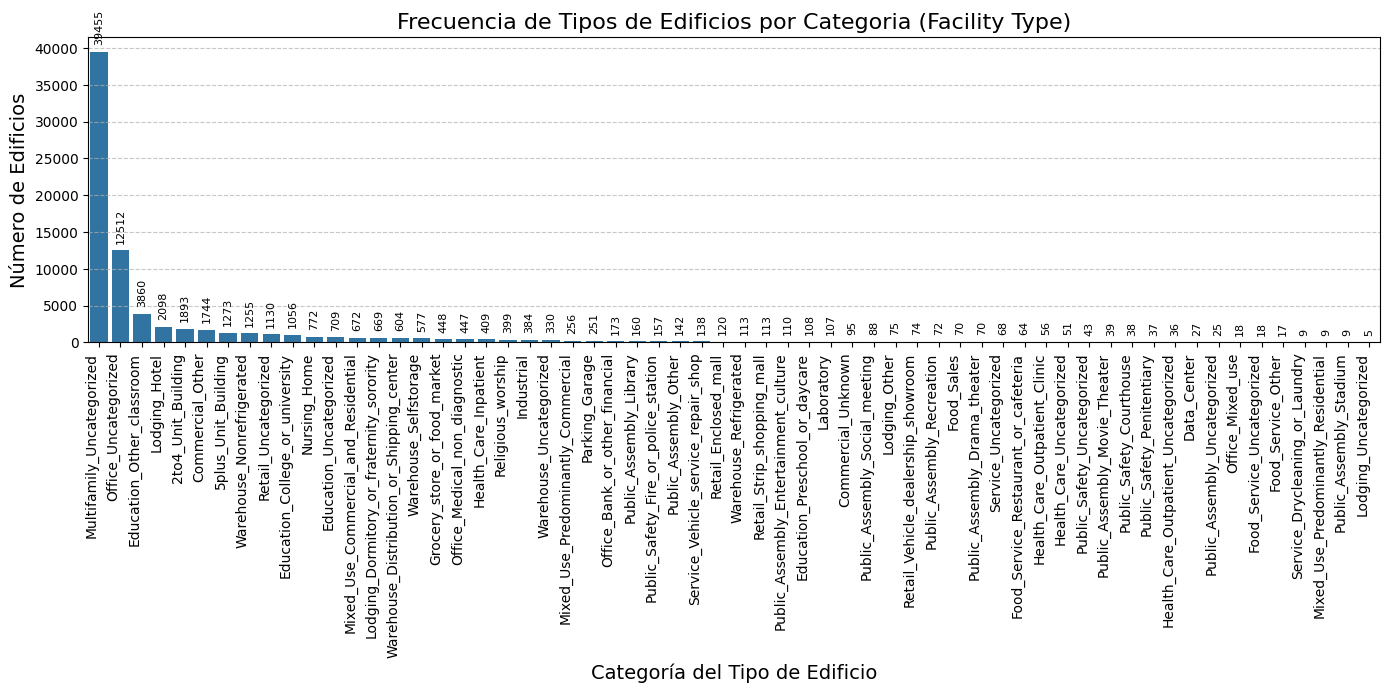

In [14]:
# Se crea el grafico
plt.figure(figsize=(14, 7))
ax = sns.countplot(data=df, x='tipo_instalacion', order=df['tipo_instalacion'].value_counts().index)

# Titulo y etiquetas
plt.title('Frecuencia de Tipos de Edificios por Categoria (Facility Type)', fontsize=16)
plt.xlabel('Categoría del Tipo de Edificio', fontsize=14)
plt.ylabel('Número de Edificios', fontsize=14)

# Rotacion del texto del eje x para mejor legibilidad
plt.xticks(rotation=90, ha='right', fontsize=10)

# Agregado de grilla para mejorar la visualización
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Agregar etiquetas de conteo encima de las barras
for container in ax.containers:
    ax.bar_label(container, label_type='edge', rotation=90, padding=5, fontsize=8)

# Mejorar el espaciado
plt.tight_layout()

plt.show()

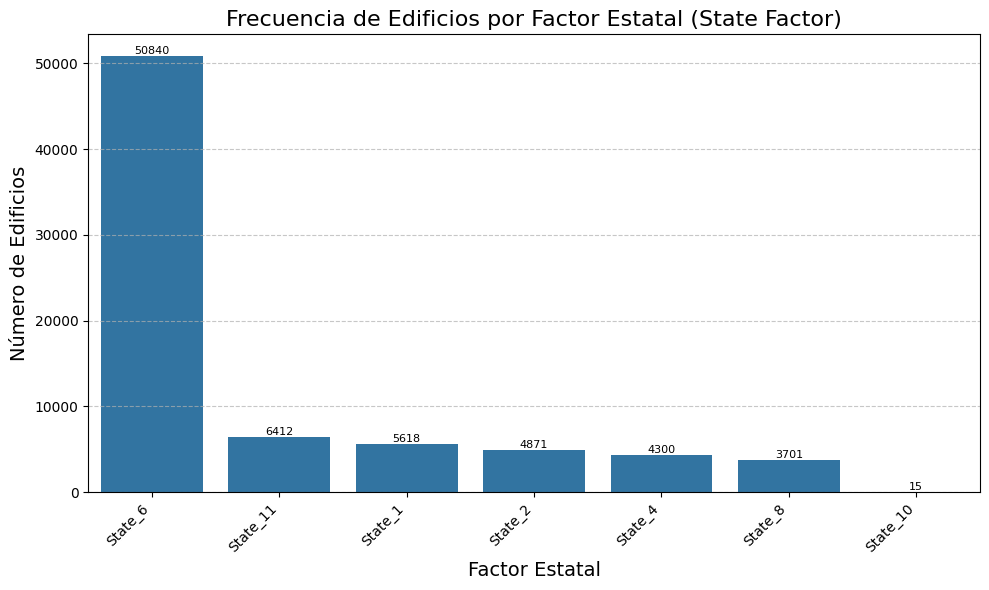

In [15]:
# Se crea el grafico
plt.figure(figsize=(10, 6))
ax = sns.countplot(data=df, x='factor_estado', order=df['factor_estado'].value_counts().index)

# Titulo y etiquetas
plt.title('Frecuencia de Edificios por Factor Estatal (State Factor)', fontsize=16)
plt.xlabel('Factor Estatal', fontsize=14)
plt.ylabel('Número de Edificios', fontsize=14)

# Rotacion del texto del eje x para mejor legibilidad
plt.xticks(rotation=45, ha='right', fontsize=10)

# Agregado de grilla para mejorar la visualización
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Agregar etiquetas de conteo encima de las barras
for container in ax.containers:
    ax.bar_label(container, label_type='edge', fontsize=8)

# Mejorar el espaciado
plt.tight_layout()

plt.show()

Tenemos 2 alternativas posibles:
* Eliminar los registros que no son muy frecuentes en el data set.
* Agrupar todos los registros que no son muy frecuentes en una nueva categorica.

### 2.5) GRAFICO DE FEATURES

Se grafica cada feature para el analisis descriptivo

In [16]:
df.columns

Index(['factor_año', 'factor_estado', 'clase_edificio', 'tipo_instalacion',
       'area_edificio', 'año_construccion', 'calificacion_energystar',
       'elevacion', 'enero_temp_min', 'enero_temp_promedio', 'enero_temp_max',
       'febrero_temp_min', 'febrero_temp_promedio', 'febrero_temp_max',
       'marzo_temp_min', 'marzo_temp_promedio', 'marzo_temp_max',
       'abril_temp_min', 'abril_temp_promedio', 'abril_temp_max',
       'mayo_temp_min', 'mayo_temp_promedio', 'mayo_temp_max',
       'junio_temp_min', 'junio_temp_promedio', 'junio_temp_max',
       'julio_temp_min', 'julio_temp_promedio', 'julio_temp_max',
       'agosto_temp_min', 'agosto_temp_promedio', 'agosto_temp_max',
       'septiembre_temp_min', 'septiembre_temp_promedio',
       'septiembre_temp_max', 'octubre_temp_min', 'octubre_temp_promedio',
       'octubre_temp_max', 'noviembre_temp_min', 'noviembre_temp_promedio',
       'noviembre_temp_max', 'diciembre_temp_min', 'diciembre_temp_promedio',
       'diciembre_t

<u>_**factor_año**_ :</u>
Año anonimizado en el que se observaron los factores de clima y uso de energía.

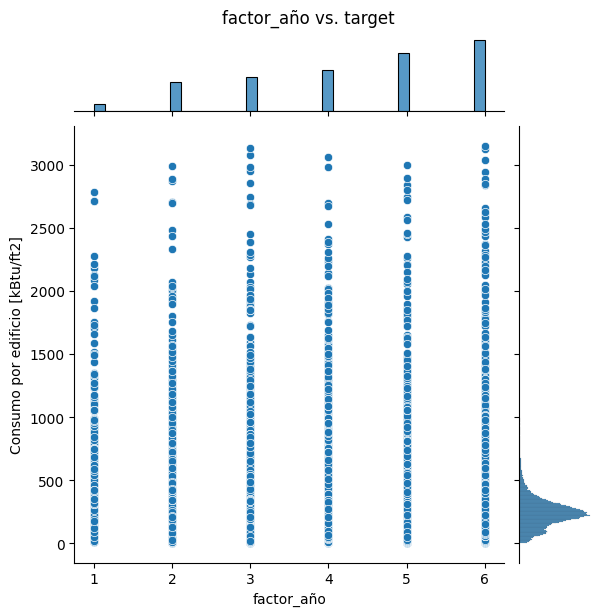

In [17]:
feature = 'factor_año'
target= 'consumo'

# Gráfico de dispersión
sns.jointplot(x=feature, y=target, data=df, kind="scatter")
plt.suptitle(f'{feature} vs. target', y=1.02)
plt.xlabel('factor_año')
plt.ylabel('Consumo por edificio [kBtu/ft2]')
plt.show()

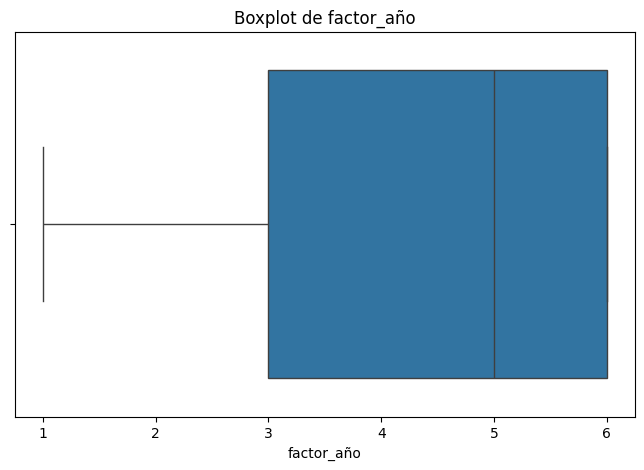

In [18]:
# Boxplot
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['factor_año'])
plt.title('Boxplot de factor_año')
plt.xlabel('factor_año')
plt.show()

Comentario:
* Se observa que con el correr de los años los registros fueron aumentando.
* No se observan datos extremos.


<u>_**factor_estado**_ :</u>
Estado anonimizado en el que se encuentra el edificio.

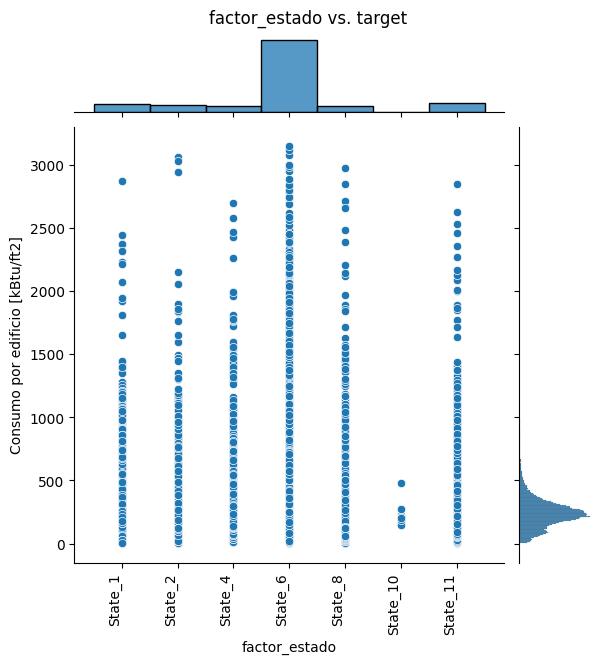

In [19]:
feature = 'factor_estado'
target= 'consumo'

# Gráfico de dispersión
sns.jointplot(x=feature, y=target, data=df, kind="scatter")
plt.suptitle(f'{feature} vs. target', y=1.02)
plt.xlabel('factor_estado')
plt.xticks(rotation=90, ha='right', fontsize=10)
plt.ylabel('Consumo por edificio [kBtu/ft2]')
plt.show()

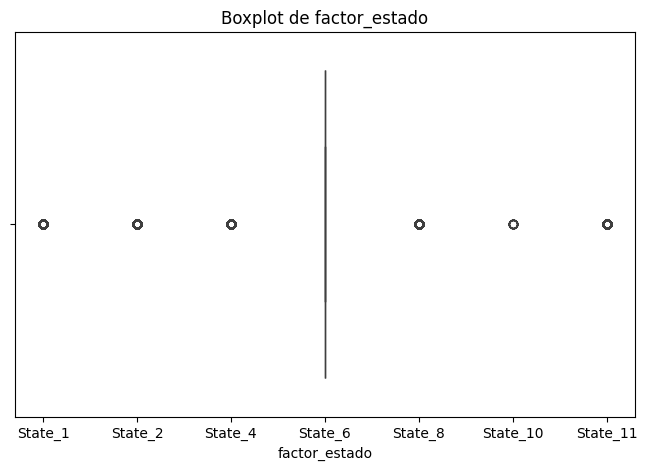

In [20]:
# Boxplot
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['factor_estado'])
plt.title('Boxplot de factor_estado')
plt.xlabel('factor_estado')
plt.show()

Se cuenta la cantidad de registros para cada estado

In [21]:
df['factor_estado'].value_counts()

,count
factor_estado,
State_6,50840
State_11,6412
State_1,5618
State_2,4871
State_4,4300
State_8,3701
State_10,15


Comentario:
* Se observa una mayor concentraciones de edificios en el _'State_6'_
* Investigar a que estado se corresponde el _'State_6'_

<u>_**clase_edificio**_ :</u>
Clasificación del edificio.

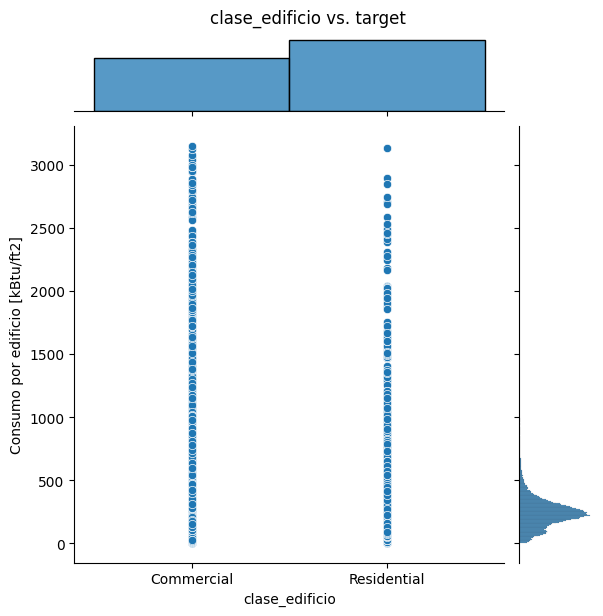

In [22]:
feature = 'clase_edificio'
target= 'consumo'

# Gráfico de dispersión
sns.jointplot(x=feature, y=target, data=df, kind="scatter")
plt.suptitle(f'{feature} vs. target', y=1.02)
plt.xlabel('clase_edificio')
plt.ylabel('Consumo por edificio [kBtu/ft2]')
plt.show()

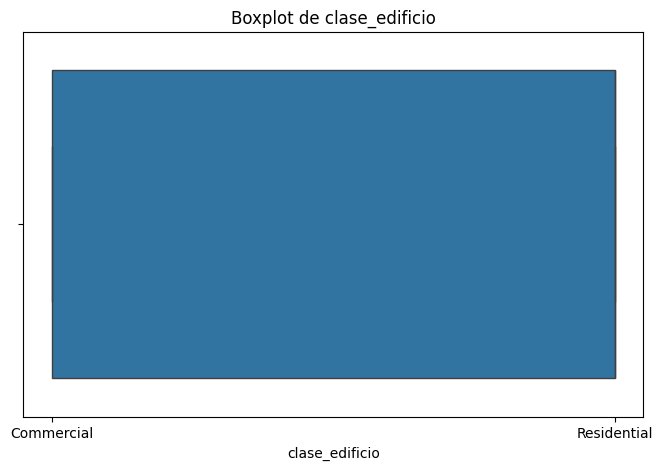

In [23]:
# Boxplot
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['clase_edificio'])
plt.title('Boxplot de clase_edificio')
plt.xlabel('clase_edificio')
plt.show()

Se calcula el porcentaje de cada categoria

In [24]:
clase_edificio_percent = df['clase_edificio'].value_counts(normalize=True) * 100
print('--Porcentaje por clase_edificio--\n')
print(clase_edificio_percent)
print('-------------------------------\n')

--Porcentaje por clase_edificio--

clase_edificio
Residential    57.496997
Commercial     42.503003
Name: proportion, dtype: float64
-------------------------------



Comentario:
* La mayoria de los edificios registrados son del tipo _'Residential'_ (57%)

<u>_**tipo_instalacion**_ :</u>
Tipo de uso del edificio.

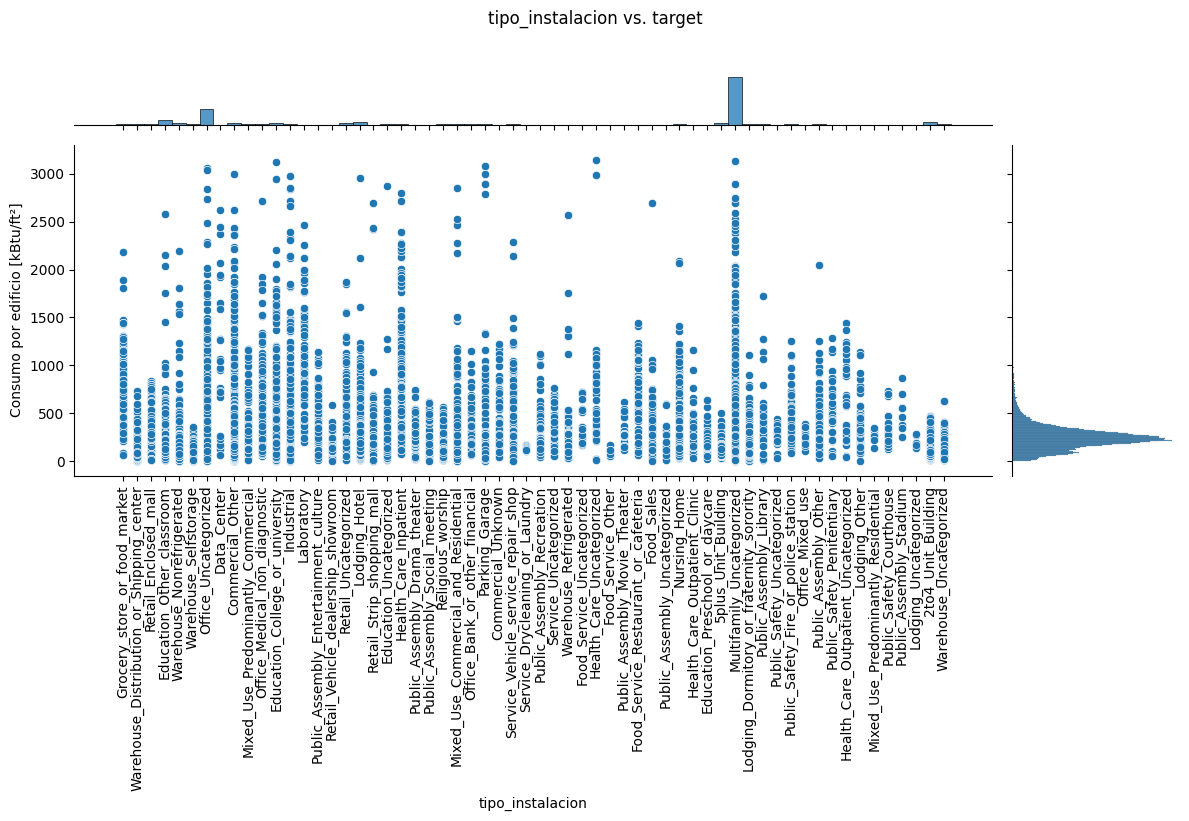

In [25]:
feature = 'tipo_instalacion'
target= 'consumo'

# Gráfico de dispersión
g = sns.jointplot(x=feature, y=target, data=df, kind="scatter")
    # Ajustar el tamaño de la figura (ancho, alto)
g.fig.set_size_inches(12, 8)  # Más ancho que alto
# Título y etiquetas
g.figure.suptitle(f'{feature} vs. target', y=1.02)
g.ax_joint.set_xlabel('tipo_instalacion')
g.ax_joint.set_ylabel('Consumo por edificio [kBtu/ft²]')
g.ax_joint.tick_params(axis='x', labelrotation=90, labelsize=10)
plt.tight_layout()
plt.show()


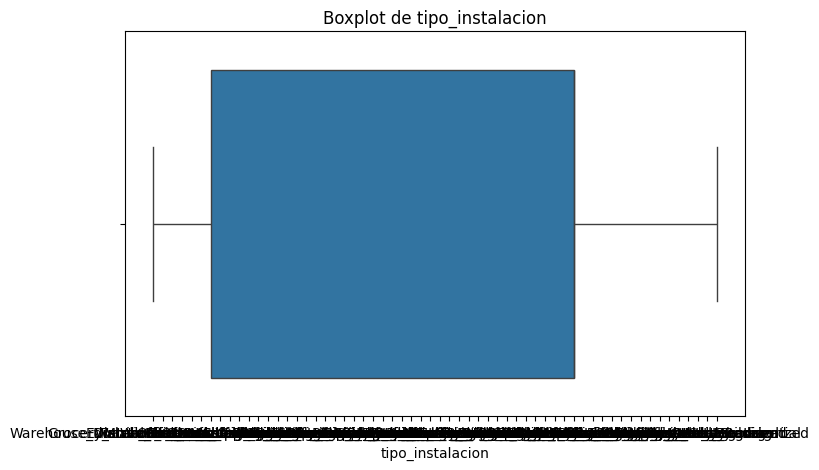

In [26]:
# Boxplot
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['tipo_instalacion'])
plt.title('Boxplot de tipo_instalacion')
plt.xlabel('tipo_instalacion')
plt.show()

Se cuenta la cantidad de registros por cada tipo de edificio

In [27]:
df['tipo_instalacion'].value_counts()

,count
tipo_instalacion,
Multifamily_Uncategorized,39455
Office_Uncategorized,12512
Education_Other_classroom,3860
Lodging_Hotel,2098
2to4_Unit_Building,1893
Commercial_Other,1744
5plus_Unit_Building,1273
Warehouse_Nonrefrigerated,1255
Retail_Uncategorized,1130


Comentario:
* La mayoria de los datos estan concentrados entre _'Multifamily_Uncategorized'_ y _'Office_Uncategorized'_.



<u>_**area_edificio**_ :</u>
Area del piso (en pies cuadrados) del edificio.

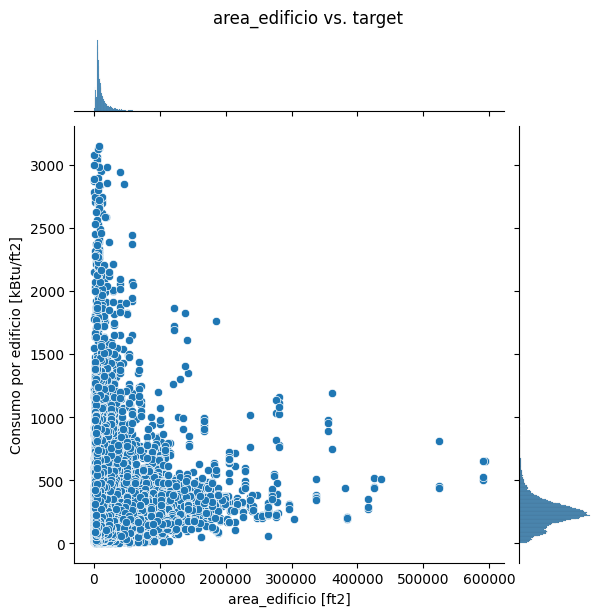

In [28]:
feature = 'area_edificio'
target= 'consumo'

# Gráfico de dispersión
sns.jointplot(x=feature, y=target, data=df, kind="scatter")
plt.suptitle(f'{feature} vs. target', y=1.02)
plt.xlabel('area_edificio [ft2]')
plt.ylabel('Consumo por edificio [kBtu/ft2]')
plt.show()

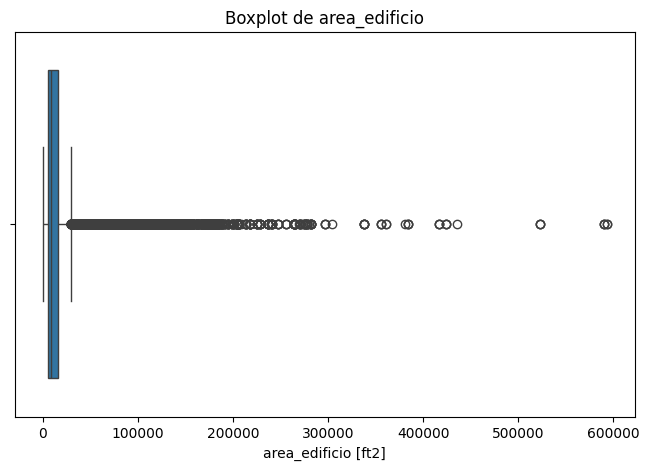

In [29]:
# Boxplot
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['area_edificio'])
plt.title('Boxplot de area_edificio')
plt.xlabel('area_edificio [ft2]')
plt.show()

Se cuenta el numero de edificios, agrupados por _'facilitiy_type'_ con una superfice _'area_edificio'_ >3e6 para conocer de que tipo son estos edificios de gran superficie.  

In [30]:
df[df['area_edificio'] > 3e6].groupby('tipo_instalacion').size().sort_values(ascending=False)

,0
tipo_instalacion,


Se cuenta el numero de edificios, agrupados por _'facilitiy_type'_ con un consumo energetico _'consumo'_ >800 (baja superficie) para conocer de que tipo son estos edificios de gran consumo.

In [31]:
df[df['consumo'] > 800].groupby('tipo_instalacion').size().sort_values(ascending=False)

,0
tipo_instalacion,
Grocery_store_or_food_market,192
Multifamily_Uncategorized,150
Health_Care_Inpatient,143
Office_Uncategorized,130
Commercial_Other,108
Laboratory,73
Industrial,58
Education_College_or_university,51
Lodging_Hotel,36


Comentario:
* Se observa que no necesariamente los edificios de mayor superficie son los que mas consumo energetico tienen, sino al contrario.
* Se observan edificios con elevadas superficies. La mayoria se corresponde con _'Office_Uncategorized'_.
* Se observan edificios, de baja superficie y con elevado consumo donde se pueden destacar del tipo _'Industrial'_, _'Multifamily_Uncategorized'_, _'Parking_Garage'_ y _'Office_Uncategorized'_.                     

<u>_**año_construccion**_ :</u>
Año en que se construyó el edificio.

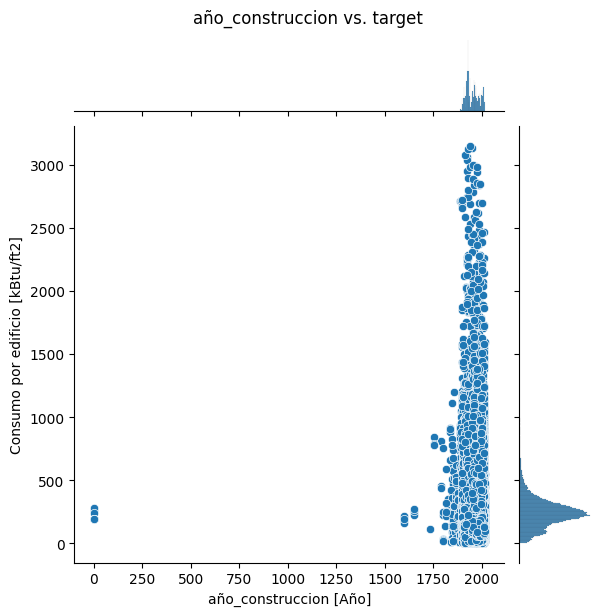

In [32]:
feature = 'año_construccion'
target= 'consumo'

# Gráfico de dispersión
sns.jointplot(x=feature, y=target, data=df, kind="scatter")
plt.suptitle(f'{feature} vs. target', y=1.02)
plt.xlabel('año_construccion [Año]')
plt.ylabel('Consumo por edificio [kBtu/ft2]')
plt.show()

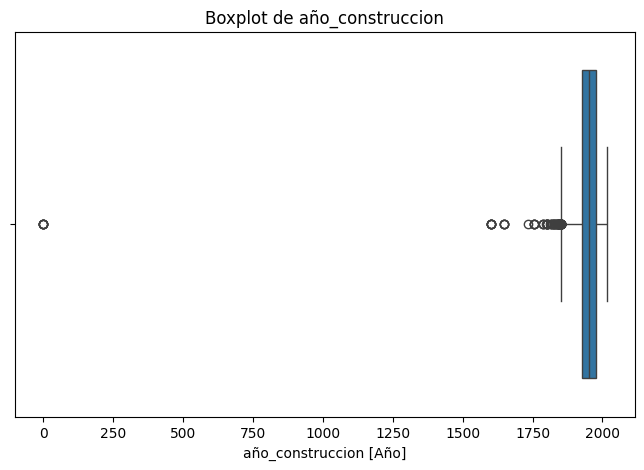

In [33]:
# Boxplot
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['año_construccion'])
plt.title('Boxplot de año_construccion')
plt.xlabel('año_construccion [Año]')
plt.show()

Se observan algunos edificios con 0 (cero) en el año de construccion, con lo cual, se filtran estos registros para observar mejor el histograma y su distribucion.

In [34]:
# Cantidad de registros con año_construccion igual a 0
df[df['año_construccion'] == 0].shape[0]

6

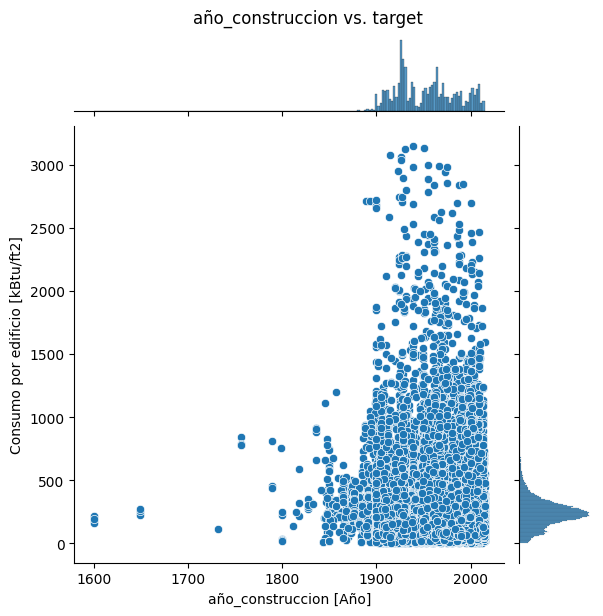

In [35]:
feature = 'año_construccion'
target= 'consumo'

# Gráfico de dispersión
sns.jointplot(x=feature, y=target, data=df[df['año_construccion']>0], kind="scatter")
plt.suptitle(f'{feature} vs. target', y=1.02)
plt.xlabel('año_construccion [Año]')
plt.ylabel('Consumo por edificio [kBtu/ft2]')
plt.show()

Comentario:
* Se observa que hay algunos edificios muy antiguos (< 1900) que no tienen mucho consumo.
* Hay una mayor concentracion de edificios entre el 1900 y la actualidad.


<u>_**calificacion_energystar**_ :</u>
Calificación de energía del edificio.

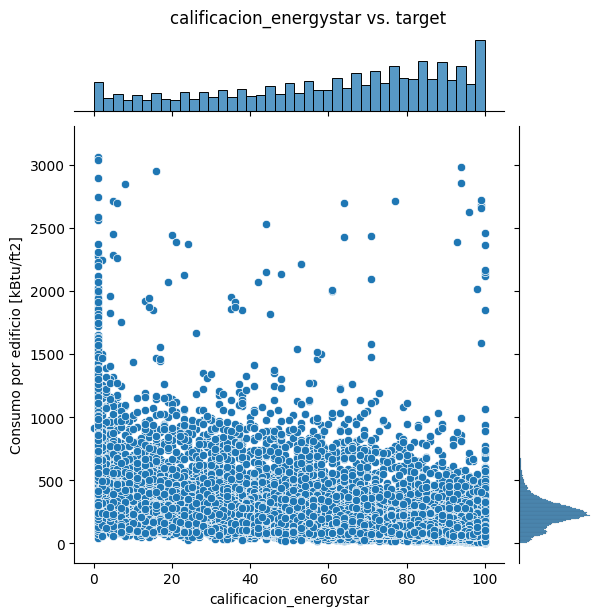

In [36]:
feature = 'calificacion_energystar'
target= 'consumo'

# Gráfico de dispersión
sns.jointplot(x=feature, y=target, data=df, kind="scatter")
plt.suptitle(f'{feature} vs. target', y=1.02)
plt.xlabel('calificacion_energystar')
plt.ylabel('Consumo por edificio [kBtu/ft2]')
plt.show()

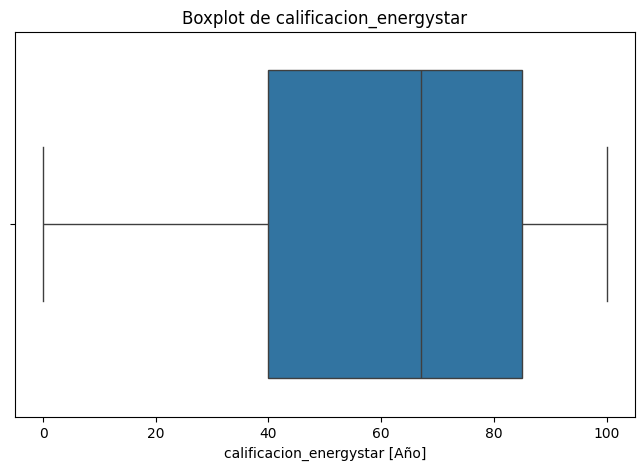

In [37]:
# Boxplot
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['calificacion_energystar'])
plt.title('Boxplot de calificacion_energystar')
plt.xlabel('calificacion_energystar [Año]')
plt.show()

Comentario:
* Se observa una cierta correlacion negativa, a medida que aumenta la calificacion del edificio disminuye el consumo, sin embargo hay registros de edificios con altos consumos para todo el rango de clasificaciones _'calificacion_energystar'_.
* Hay una concentracion muy grande de edificios con clasificacion 100, donde se observan que alguno de ellos tambien tienen un alto consumo. La mayoria son del tipo _'Industrial'_.

Se cuenta la cantidad de edificios con buena clasificacion energetica que presentan un elevado consumo.

In [38]:
df[(df['calificacion_energystar'] > 80) & (df['consumo'] > 500)].groupby('tipo_instalacion').size().sort_values(ascending=False)

,0
tipo_instalacion,
Health_Care_Inpatient,34
Grocery_store_or_food_market,30
Office_Uncategorized,15
Multifamily_Uncategorized,10
Industrial,10
Retail_Uncategorized,8
Nursing_Home,7
Mixed_Use_Commercial_and_Residential,4
Commercial_Other,4


<u>_**elevacion**_ :</u>
Elevación de la ubicación del edificio (en m).

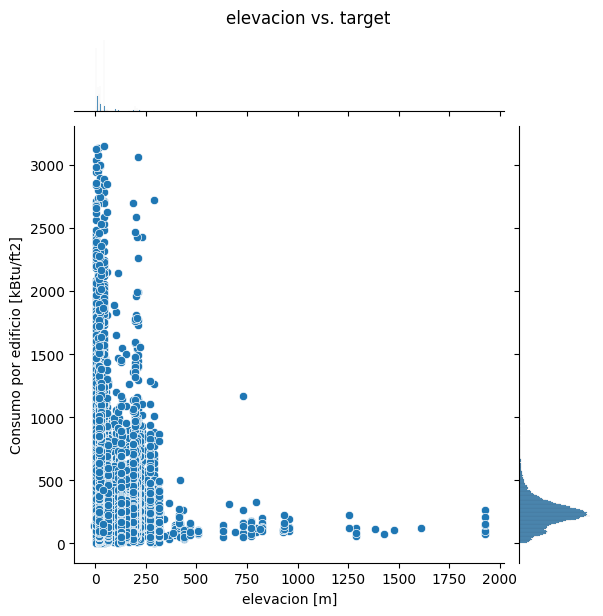

In [39]:
feature = 'elevacion'
target= 'consumo'

# Gráfico de dispersión
sns.jointplot(x=feature, y=target, data=df, kind="scatter")
plt.suptitle(f'{feature} vs. target', y=1.02)
plt.xlabel('elevacion [m]')
plt.ylabel('Consumo por edificio [kBtu/ft2]')
plt.show()

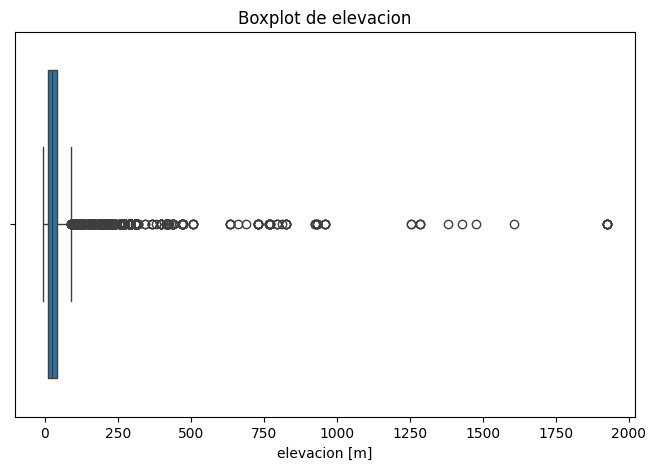

In [40]:
# Boxplot
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['elevacion'])
plt.title('Boxplot de elevacion')
plt.xlabel('elevacion [m]')
plt.show()

Comentario:
* Se observa una correlacion negativa, a medida que la elevacion aumenta, el consumo dismuniye.
* Se observan valores extremos que se corresponden con aquello de mayor altura.
* Se observa que los edificios ubicados en elevaciones mayores a 500m son del tipo _'Education_Uncategorized'_ y presentan un consumo energetico bajo.

Se cuenta la cantidad de edificios con _'elevacion'_>500 que presentan un bajo consumo, para conocer que tipo de edificios son.

In [41]:
df[(df['elevacion'] > 500)].groupby('tipo_instalacion').size().sort_values(ascending=False)

,0
tipo_instalacion,
Education_Uncategorized,63


<u>_**enero_temp_min**_ :</u>
Temperatura mínima en enero (en grados Fahrenheit) en la ubicación del edificio.

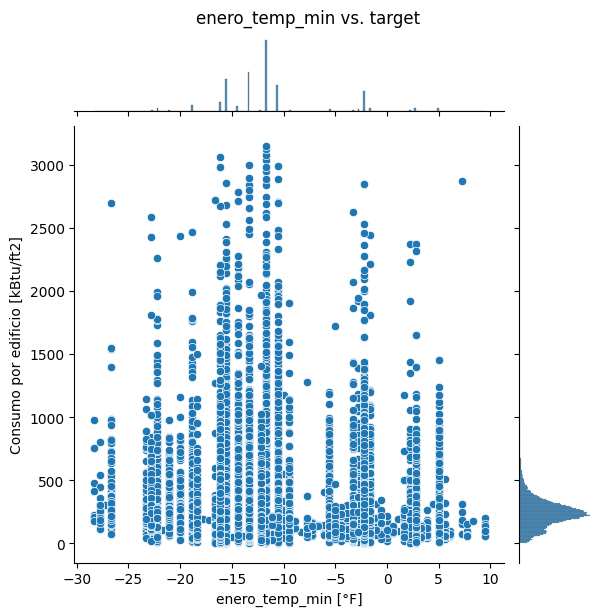

In [42]:
feature = 'enero_temp_min'
target= 'consumo'

# Gráfico de dispersión
sns.jointplot(x=feature, y=target, data=df, kind="scatter")
plt.suptitle(f'{feature} vs. target', y=1.02)
plt.xlabel('enero_temp_min [°F]')
plt.ylabel('Consumo por edificio [kBtu/ft2]')
plt.show()

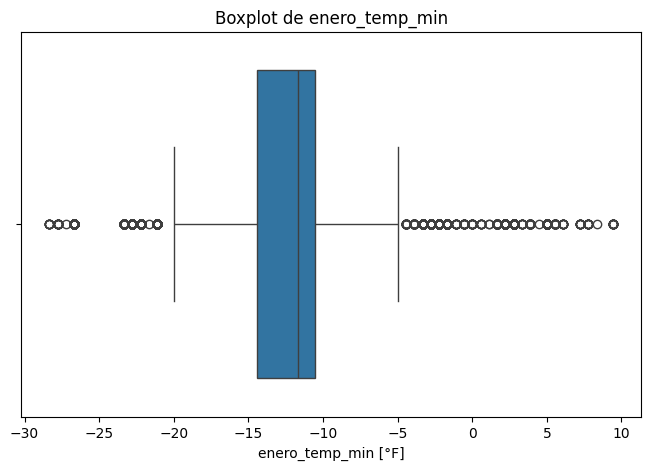

In [43]:
# Boxplot
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['enero_temp_min'])
plt.title('Boxplot de enero_temp_min')
plt.xlabel('enero_temp_min [°F]')
plt.show()

Comentario:
* ...
* ...

<u>_**grados_dia_enfriamiento**_ :</u>
El día grado de refrigeración para un día dado es el número de grados en que la temperatura promedio diaria supera los 65 grados Fahrenheit (18,3°C). Cada mes se suma para producir un total anual en la ubicación del edificio.

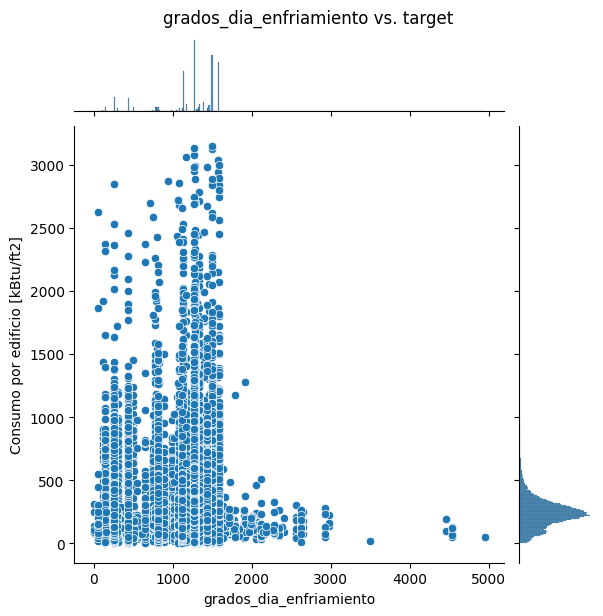

In [44]:
feature = 'grados_dia_enfriamiento'
target= 'consumo'

# Gráfico de dispersión
sns.jointplot(x=feature, y=target, data=df, kind="scatter")
plt.suptitle(f'{feature} vs. target', y=1.02)
plt.xlabel('grados_dia_enfriamiento')
plt.ylabel('Consumo por edificio [kBtu/ft2]')
plt.show()

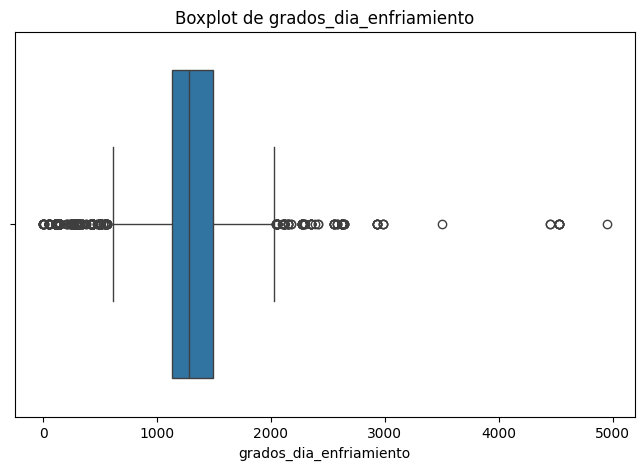

In [45]:
# Boxplot
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['grados_dia_enfriamiento'])
plt.title('Boxplot de grados_dia_enfriamiento')
plt.xlabel('grados_dia_enfriamiento')
plt.show()

Comentario:
* ...
* ...

<u>_**grados_dia_calefaccion**_ :</u>
Día grado de calefacción para un día dado es el número de grados en que la temperatura promedio diaria cae por debajo de los 65 grados Fahrenheit (18,3°C). Cada mes se suma para producir un total anual en la ubicación del edificio.

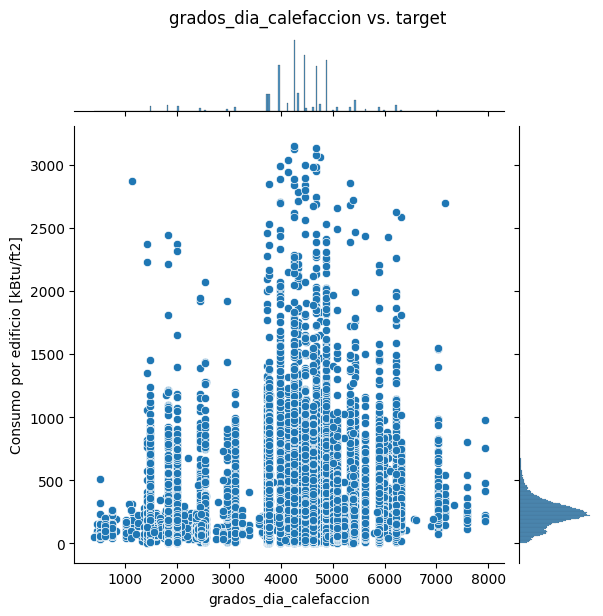

In [46]:
feature = 'grados_dia_calefaccion'
target= 'consumo'

# Gráfico de dispersión
sns.jointplot(x=feature, y=target, data=df, kind="scatter")
plt.suptitle(f'{feature} vs. target', y=1.02)
plt.xlabel('grados_dia_calefaccion')
plt.ylabel('Consumo por edificio [kBtu/ft2]')
plt.show()

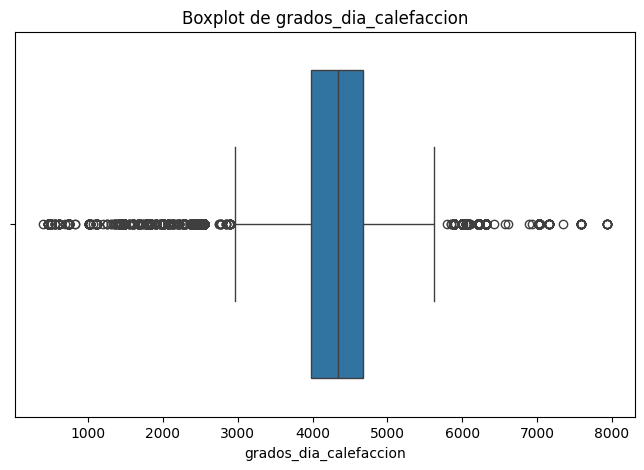

In [47]:
# Boxplot
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['grados_dia_calefaccion'])
plt.title('Boxplot de grados_dia_calefaccion')
plt.xlabel('grados_dia_calefaccion')
plt.show()

Comentario:
* ...
* ...

<u>_**precipitacion_mm**_ :</u>
Precipitación anual en pulgadas en la ubicación del edificio.

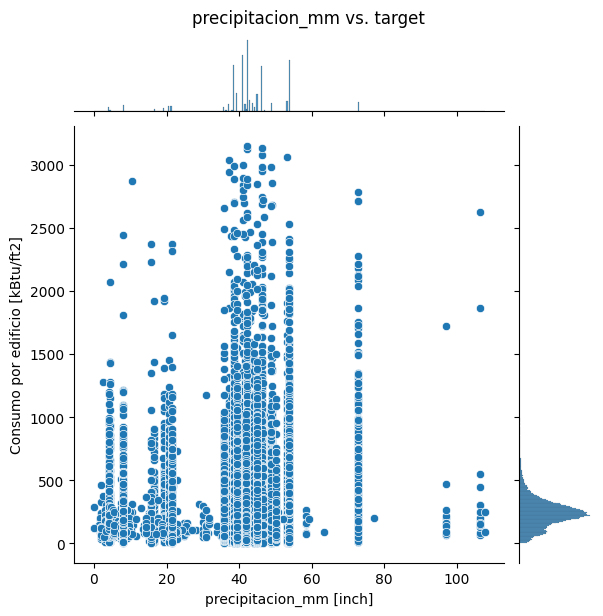

In [48]:
feature = 'precipitacion_mm'
target= 'consumo'

# Gráfico de dispersión
sns.jointplot(x=feature, y=target, data=df, kind="scatter")
plt.suptitle(f'{feature} vs. target', y=1.02)
plt.xlabel('precipitacion_mm [inch]')
plt.ylabel('Consumo por edificio [kBtu/ft2]')
plt.show()

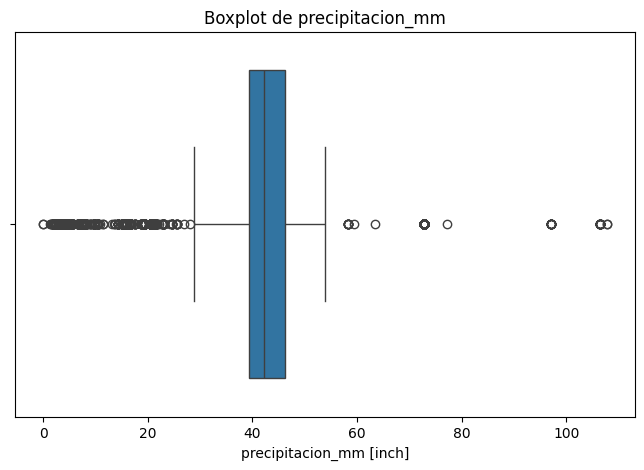

In [49]:
# Boxplot
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['precipitacion_mm'])
plt.title('Boxplot de precipitacion_mm')
plt.xlabel('precipitacion_mm [inch]')
plt.show()

Comentario:
* ...
* ...

<u>_**nevada_mm**_ :</u>
Caída de nieve anual en pulgadas en la ubicación del edificio.

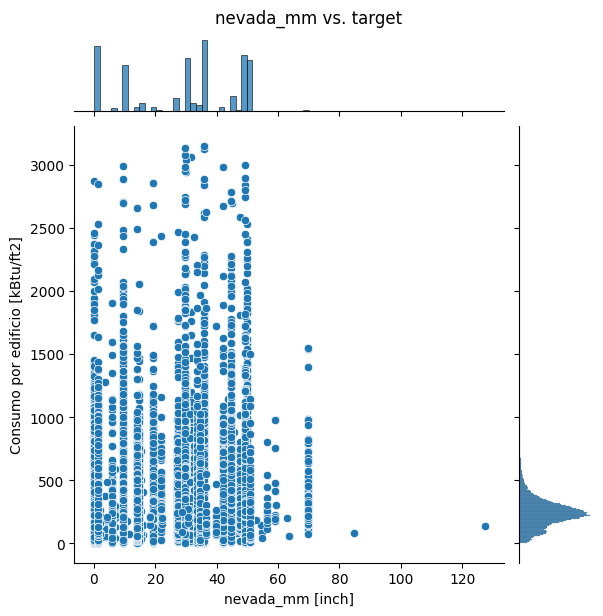

In [50]:
feature = 'nevada_mm'
target= 'consumo'

# Gráfico de dispersión
sns.jointplot(x=feature, y=target, data=df, kind="scatter")
plt.suptitle(f'{feature} vs. target', y=1.02)
plt.xlabel('nevada_mm [inch]')
plt.ylabel('Consumo por edificio [kBtu/ft2]')
plt.show()

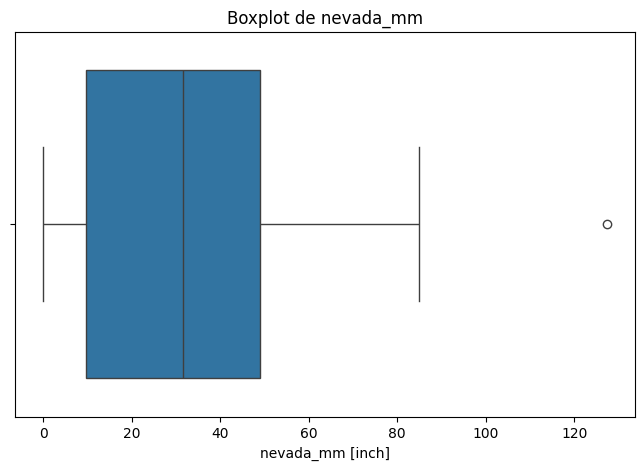

In [51]:
# Boxplot
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['nevada_mm'])
plt.title('Boxplot de nevada_mm')
plt.xlabel('nevada_mm [inch]')
plt.show()

Comentario:
* ...
* ...

<u>_**snowdepth_inches**_ :</u>
Profundidad de nieve anual en pulgadas en la ubicación del edificio.

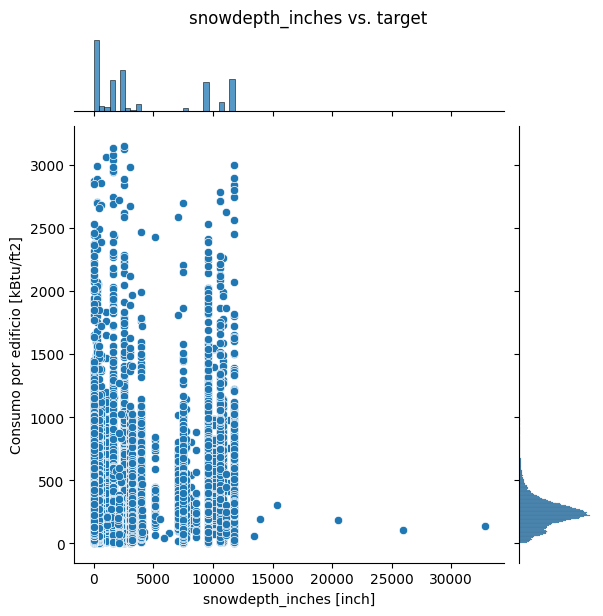

In [52]:
feature = 'snowdepth_inches'
target= 'consumo'

# Gráfico de dispersión
sns.jointplot(x=feature, y=target, data=df, kind="scatter")
plt.suptitle(f'{feature} vs. target', y=1.02)
plt.xlabel('snowdepth_inches [inch]')
plt.ylabel('Consumo por edificio [kBtu/ft2]')
plt.show()

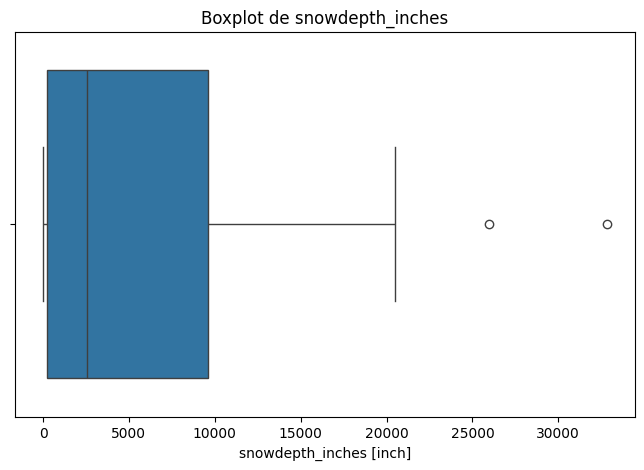

In [53]:
# Boxplot
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['snowdepth_inches'])
plt.title('Boxplot de snowdepth_inches')
plt.xlabel('snowdepth_inches [inch]')
plt.show()

Comentario:
* ...
* ...

<u>_**avg_temp**_ :</u>
Temperatura promedio durante un año en la ubicación del edificio.

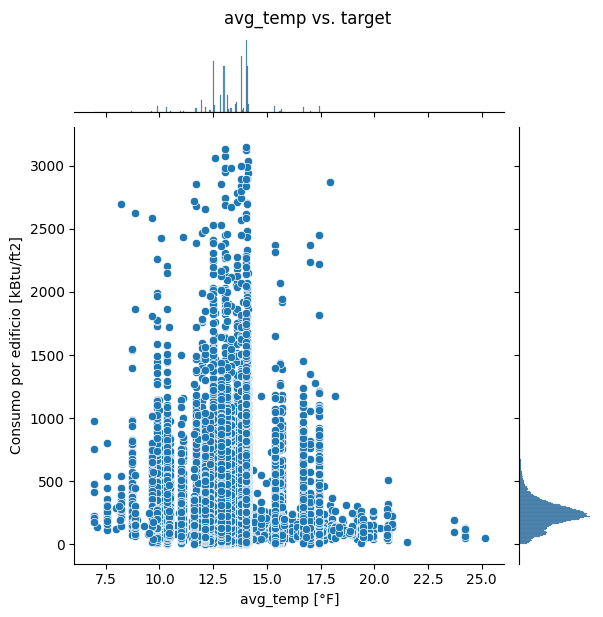

In [54]:
feature = 'avg_temp'
target= 'consumo'

# Gráfico de dispersión
sns.jointplot(x=feature, y=target, data=df, kind="scatter")
plt.suptitle(f'{feature} vs. target', y=1.02)
plt.xlabel('avg_temp [°F]')
plt.ylabel('Consumo por edificio [kBtu/ft2]')
plt.show()

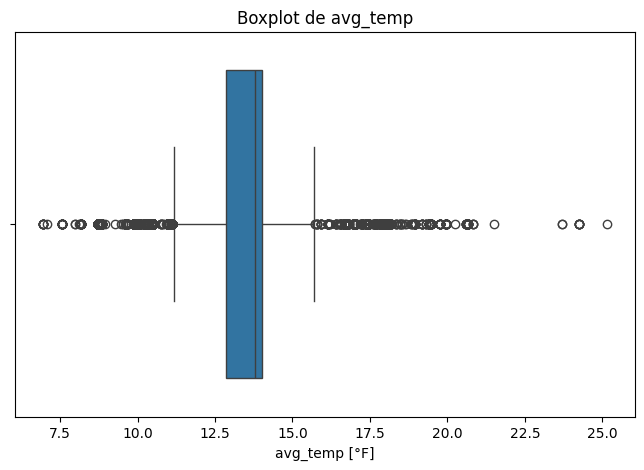

In [55]:
# Boxplot
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['avg_temp'])
plt.title('Boxplot de avg_temp')
plt.xlabel('avg_temp [°F]')
plt.show()

Comentario:
* ...
* ...

<u>_**dias_menos_1C**_ :</u>
Número total de días por debajo de 30 grados Fahrenheit en la ubicación del edificio.

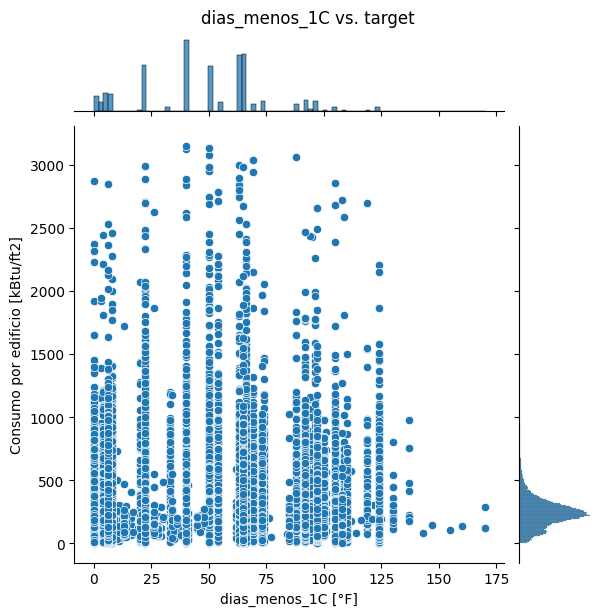

In [56]:
feature = 'dias_menos_1C'
target= 'consumo'

# Gráfico de dispersión
sns.jointplot(x=feature, y=target, data=df, kind="scatter")
plt.suptitle(f'{feature} vs. target', y=1.02)
plt.xlabel('dias_menos_1C [°F]')
plt.ylabel('Consumo por edificio [kBtu/ft2]')
plt.show()

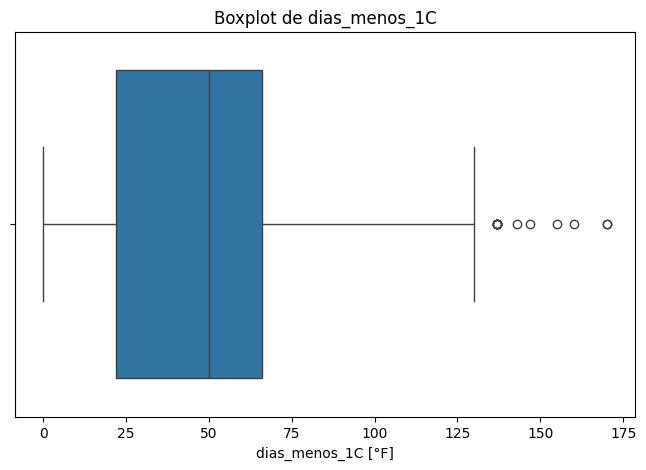

In [57]:
# Boxplot
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['dias_menos_1C'])
plt.title('Boxplot de dias_menos_1C')
plt.xlabel('dias_menos_1C [°F]')
plt.show()

Comentario:
* ...
* ...

<u>_**dias_menos_6C**_ :</u>
Número total de días por debajo de 20 grados Fahrenheit en la ubicación del edificio.

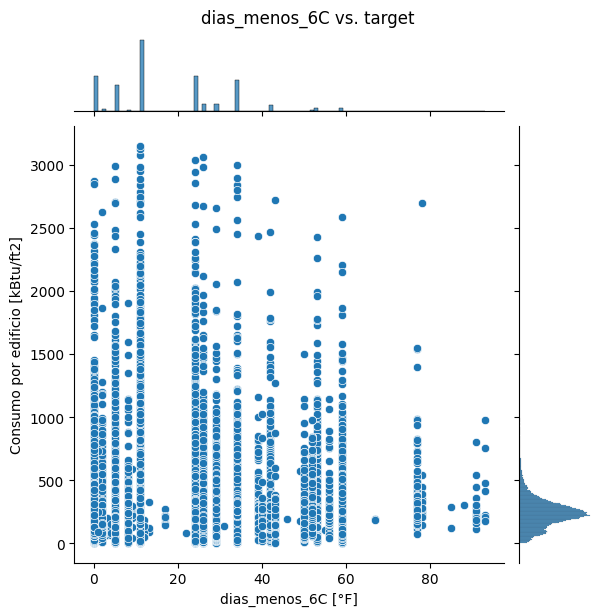

In [58]:
feature = 'dias_menos_6C'
target= 'consumo'

# Gráfico de dispersión
sns.jointplot(x=feature, y=target, data=df, kind="scatter")
plt.suptitle(f'{feature} vs. target', y=1.02)
plt.xlabel('dias_menos_6C [°F]')
plt.ylabel('Consumo por edificio [kBtu/ft2]')
plt.show()

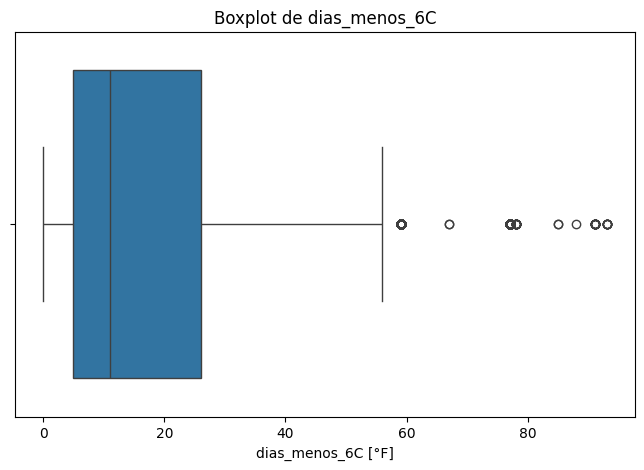

In [59]:
# Boxplot
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['dias_menos_6C'])
plt.title('Boxplot de dias_menos_6C')
plt.xlabel('dias_menos_6C [°F]')
plt.show()

Comentario:
* ...
* ...

<u>_**dias_menos_12C**_ :</u>
Número total de días por debajo de 10 grados Fahrenheit en la ubicación del edificio.

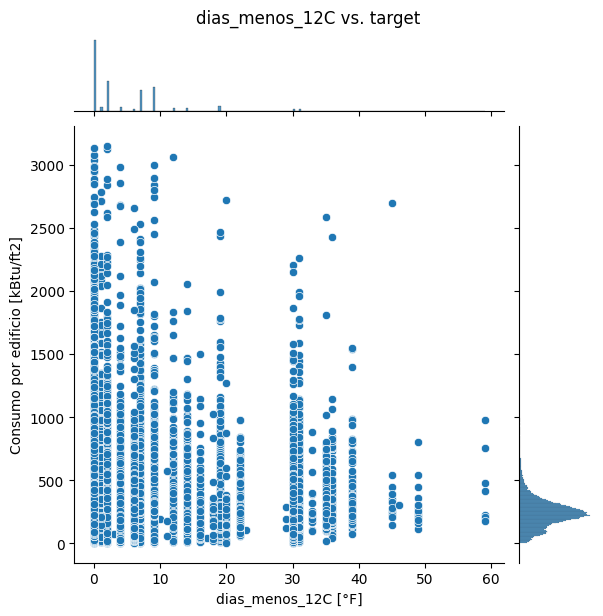

In [60]:
feature = 'dias_menos_12C'
target= 'consumo'

# Gráfico de dispersión
sns.jointplot(x=feature, y=target, data=df, kind="scatter")
plt.suptitle(f'{feature} vs. target', y=1.02)
plt.xlabel('dias_menos_12C [°F]')
plt.ylabel('Consumo por edificio [kBtu/ft2]')
plt.show()

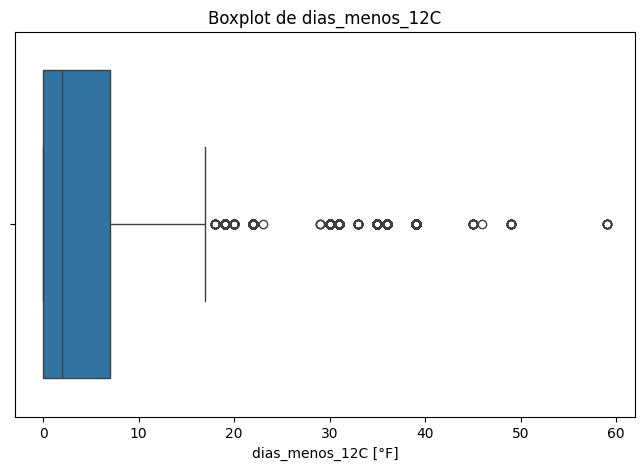

In [61]:
# Boxplot
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['dias_menos_12C'])
plt.title('Boxplot de dias_menos_12C')
plt.xlabel('dias_menos_12C [°F]')
plt.show()

Comentario:
* ...
* ...

<u>_**dias_menos_18C**_ :</u>
Número total de días por debajo de 0 grados Fahrenheit en la ubicación del edificio.

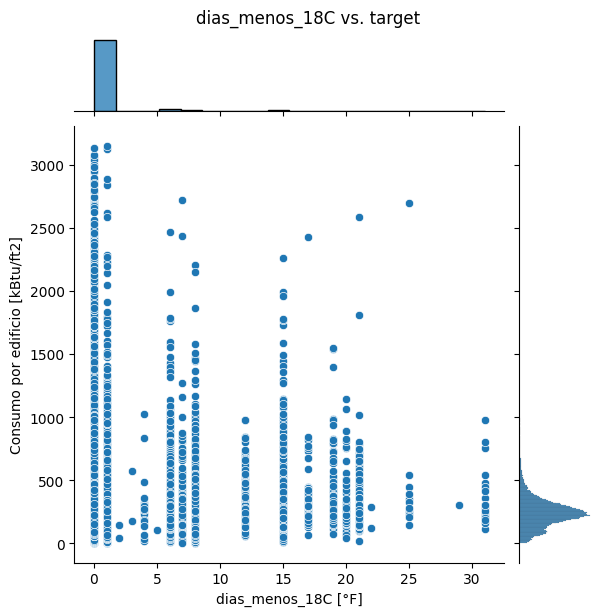

In [62]:
feature = 'dias_menos_18C'
target= 'consumo'

# Gráfico de dispersión
sns.jointplot(x=feature, y=target, data=df, kind="scatter")
plt.suptitle(f'{feature} vs. target', y=1.02)
plt.xlabel('dias_menos_18C [°F]')
plt.ylabel('Consumo por edificio [kBtu/ft2]')
plt.show()

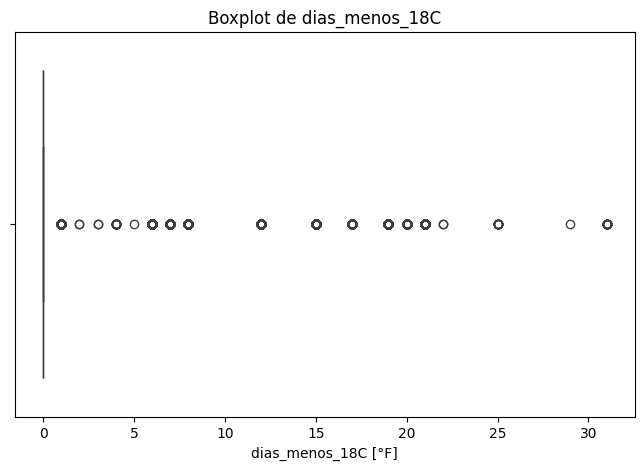

In [63]:
# Boxplot
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['dias_menos_18C'])
plt.title('Boxplot de dias_menos_18C')
plt.xlabel('dias_menos_18C [°F]')
plt.show()

Comentario:
* ...
* ...

<u>_**dias_mas_27C**_ :</u>
Número total de días por encima de 80 grados Fahrenheit en la ubicación del edificio.

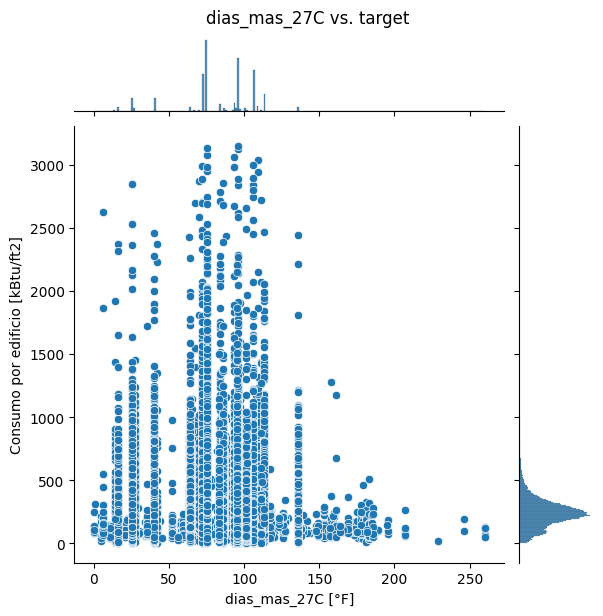

In [64]:
feature = 'dias_mas_27C'
target= 'consumo'

# Gráfico de dispersión
sns.jointplot(x=feature, y=target, data=df, kind="scatter")
plt.suptitle(f'{feature} vs. target', y=1.02)
plt.xlabel('dias_mas_27C [°F]')
plt.ylabel('Consumo por edificio [kBtu/ft2]')
plt.show()

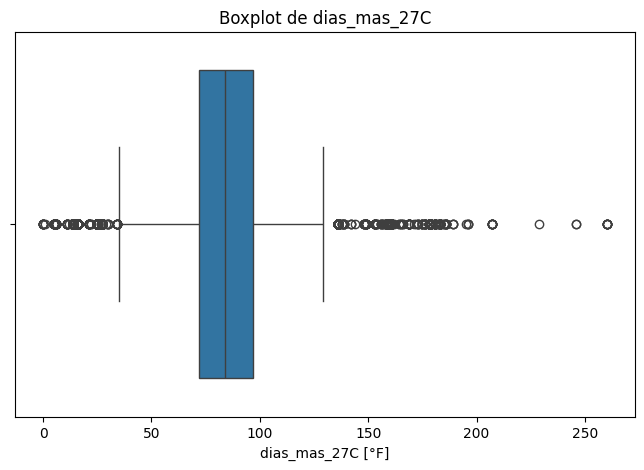

In [65]:
# Boxplot
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['dias_mas_27C'])
plt.title('Boxplot de dias_mas_27C')
plt.xlabel('dias_mas_27C [°F]')
plt.show()

Comentario:
* ...
* ...

<u>_**dias_mas_32C**_ :</u>
Número total de días por encima de 90 grados Fahrenheit en la ubicación del edificio.

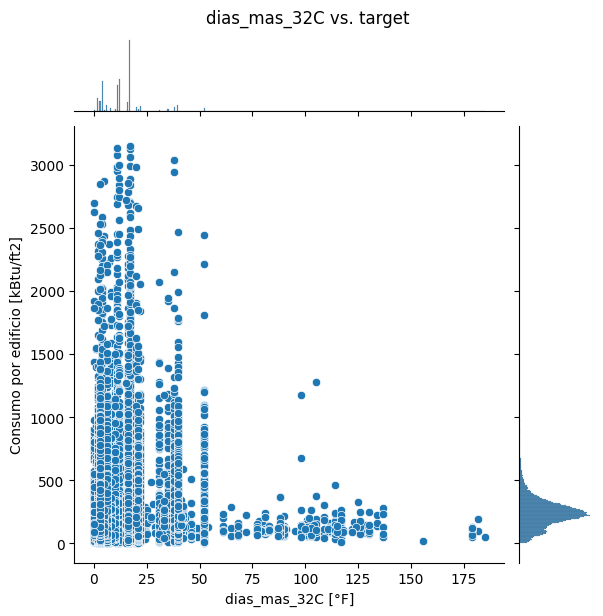

In [66]:
feature = 'dias_mas_32C'
target= 'consumo'

# Gráfico de dispersión
sns.jointplot(x=feature, y=target, data=df, kind="scatter")
plt.suptitle(f'{feature} vs. target', y=1.02)
plt.xlabel('dias_mas_32C [°F]')
plt.ylabel('Consumo por edificio [kBtu/ft2]')
plt.show()

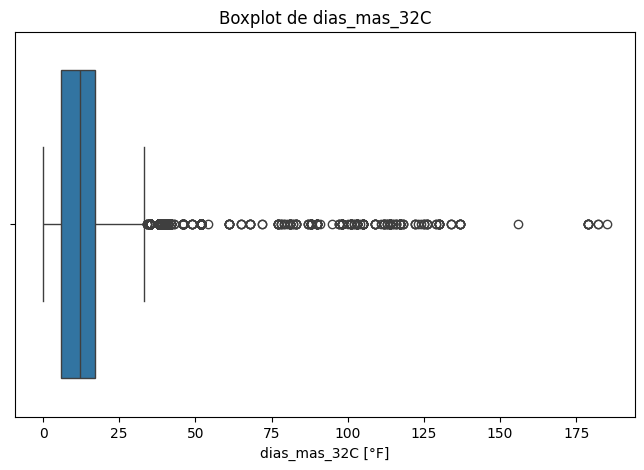

In [67]:
# Boxplot
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['dias_mas_32C'])
plt.title('Boxplot de dias_mas_32C')
plt.xlabel('dias_mas_32C [°F]')
plt.show()

Comentario:
* ...
* ...

<u>_**dias_mas_38C**_ :</u>
Número total de días por encima de 100 grados Fahrenheit en la ubicación del edificio.

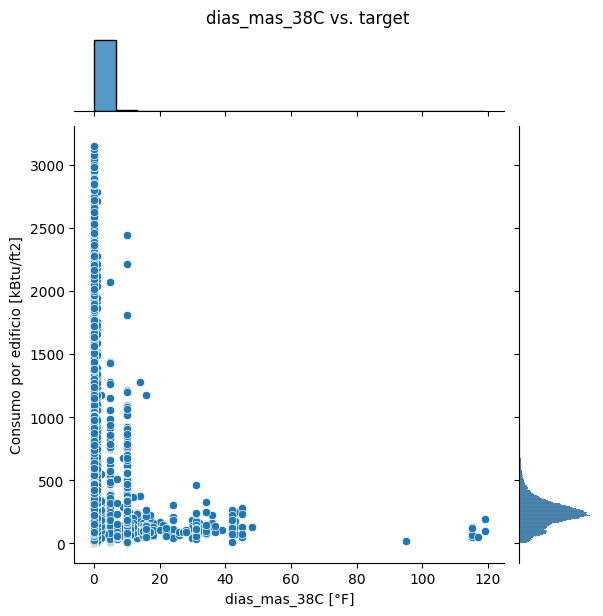

In [68]:
feature = 'dias_mas_38C'
target= 'consumo'

# Gráfico de dispersión
sns.jointplot(x=feature, y=target, data=df, kind="scatter")
plt.suptitle(f'{feature} vs. target', y=1.02)
plt.xlabel('dias_mas_38C [°F]')
plt.ylabel('Consumo por edificio [kBtu/ft2]')
plt.show()

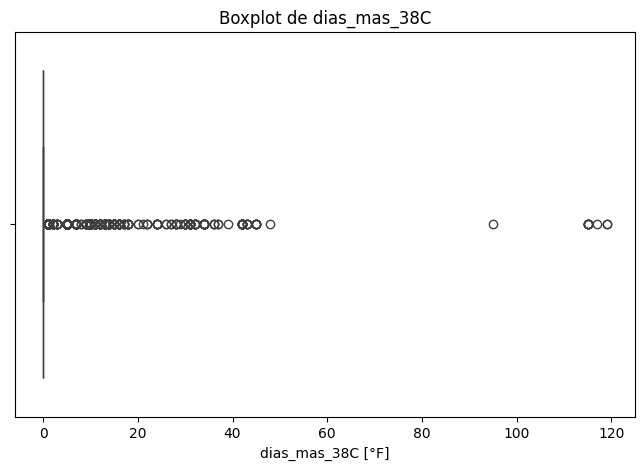

In [69]:
# Boxplot
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['dias_mas_38C'])
plt.title('Boxplot de dias_mas_38C')
plt.xlabel('dias_mas_38C [°F]')
plt.show()

Comentario:
* ...
* ...

<u>_**dias_mas_43C**_ :</u>
Número total de días por encima de 110 grados Fahrenheit en la ubicación del edificio.

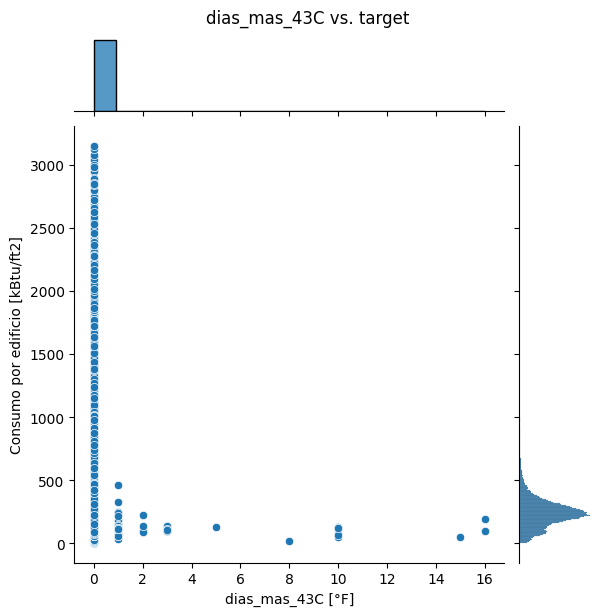

In [70]:
feature = 'dias_mas_43C'
target= 'consumo'

# Gráfico de dispersión
sns.jointplot(x=feature, y=target, data=df, kind="scatter")
plt.suptitle(f'{feature} vs. target', y=1.02)
plt.xlabel('dias_mas_43C [°F]')
plt.ylabel('Consumo por edificio [kBtu/ft2]')
plt.show()

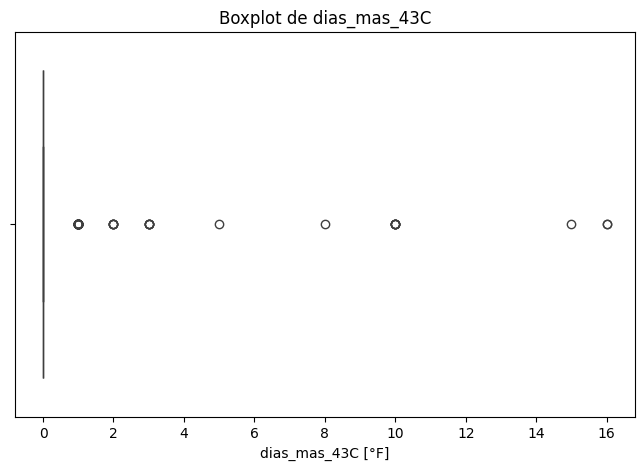

In [71]:
# Boxplot
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['dias_mas_43C'])
plt.title('Boxplot de dias_mas_43C')
plt.xlabel('dias_mas_43C [°F]')
plt.show()

Comentario:
* ...
* ...

<u>_**direccion_velocidad_viento_maxima**_ :</u>
Dirección del viento para la velocidad máxima del viento en la ubicación del edificio. Dado en direcciones de puntos cardinales de 360 grados (por ejemplo, 360 = norte, 180 = sur, etc.).

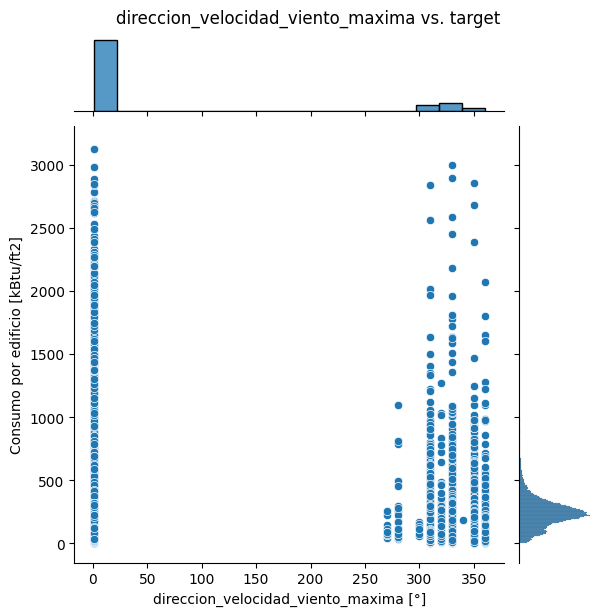

In [72]:
feature = 'direccion_velocidad_viento_maxima'
target= 'consumo'

# Gráfico de dispersión
sns.jointplot(x=feature, y=target, data=df, kind="scatter")
plt.suptitle(f'{feature} vs. target', y=1.02)
plt.xlabel('direccion_velocidad_viento_maxima [°]')
plt.ylabel('Consumo por edificio [kBtu/ft2]')
plt.show()

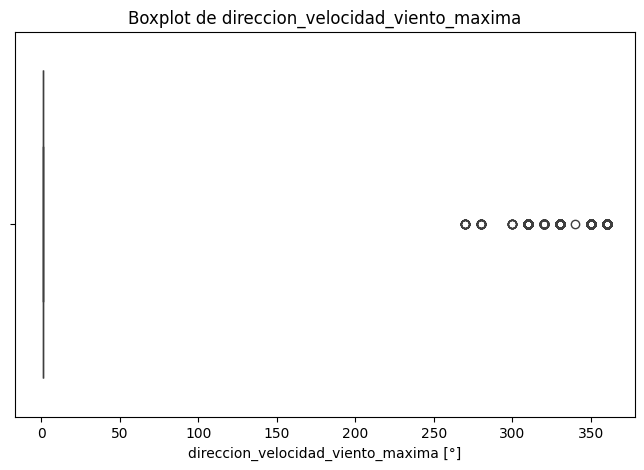

In [73]:
# Boxplot
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['direccion_velocidad_viento_maxima'])
plt.title('Boxplot de direccion_velocidad_viento_maxima')
plt.xlabel('direccion_velocidad_viento_maxima [°]')
plt.show()

Comentario:
* ...
* ...

<u>_**direccion_velocidad_viento_pico**_ :</u>
Dirección del viento para la velocidad máxima de ráfaga de viento en la ubicación del edificio. Dado en direcciones de puntos cardinales de 360 grados (por ejemplo, 360 = norte, 180 = sur, etc.).

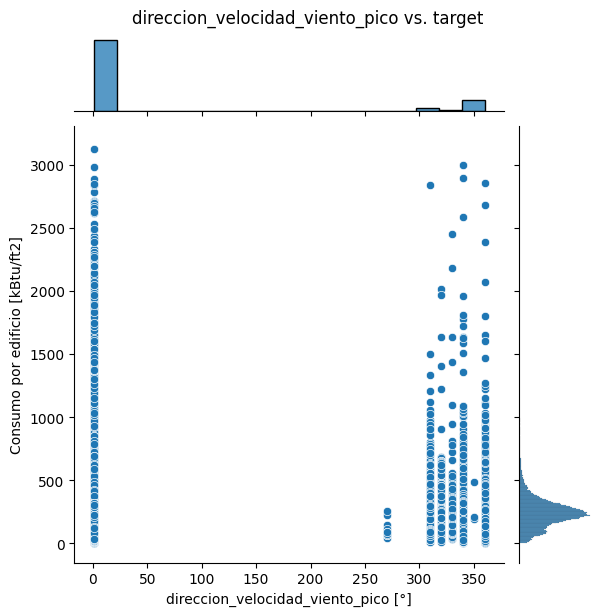

In [74]:
feature = 'direccion_velocidad_viento_pico'
target= 'consumo'

# Gráfico de dispersión
sns.jointplot(x=feature, y=target, data=df, kind="scatter")
plt.suptitle(f'{feature} vs. target', y=1.02)
plt.xlabel('direccion_velocidad_viento_pico [°]')
plt.ylabel('Consumo por edificio [kBtu/ft2]')
plt.show()

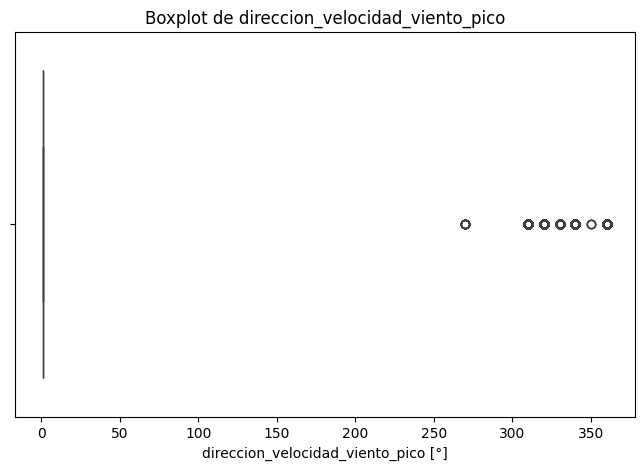

In [75]:
# Boxplot
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['direccion_velocidad_viento_pico'])
plt.title('Boxplot de direccion_velocidad_viento_pico')
plt.xlabel('direccion_velocidad_viento_pico [°]')
plt.show()

Comentario:
* ...
* ...

<u>_**velocidad_viento_maxima**_ :</u>
Velocidad máxima del viento en la ubicación del edificio.

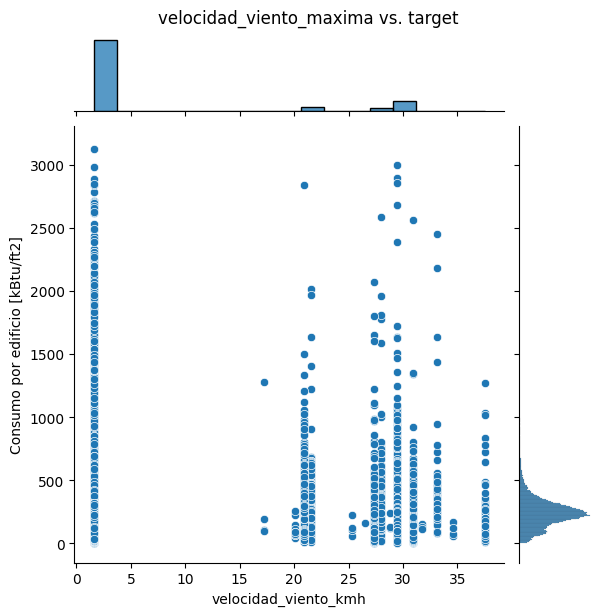

In [76]:
feature = 'velocidad_viento_maxima'
target= 'consumo'

# Gráfico de dispersión
sns.jointplot(x=feature, y=target, data=df, kind="scatter")
plt.suptitle(f'{feature} vs. target', y=1.02)
plt.xlabel('velocidad_viento_kmh')
plt.ylabel('Consumo por edificio [kBtu/ft2]')
plt.show()

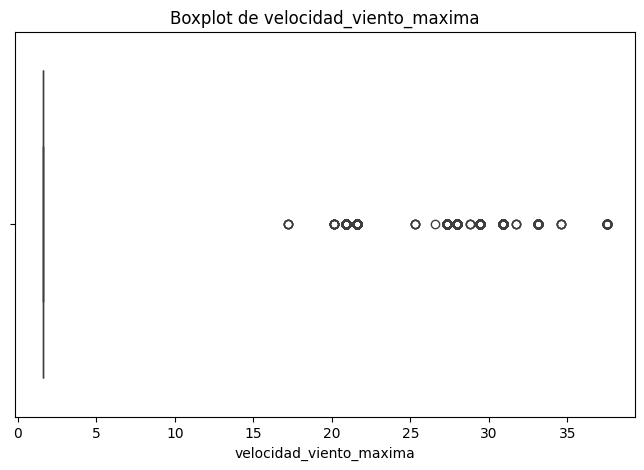

In [77]:
# Boxplot
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['velocidad_viento_maxima'])
plt.title('Boxplot de velocidad_viento_maxima')
plt.xlabel('velocidad_viento_maxima')
plt.show()

Comentario:
* ...
* ...

<u>_**dias_con_niebla**_ :</u>
Número de días con niebla en la ubicación del edificio.

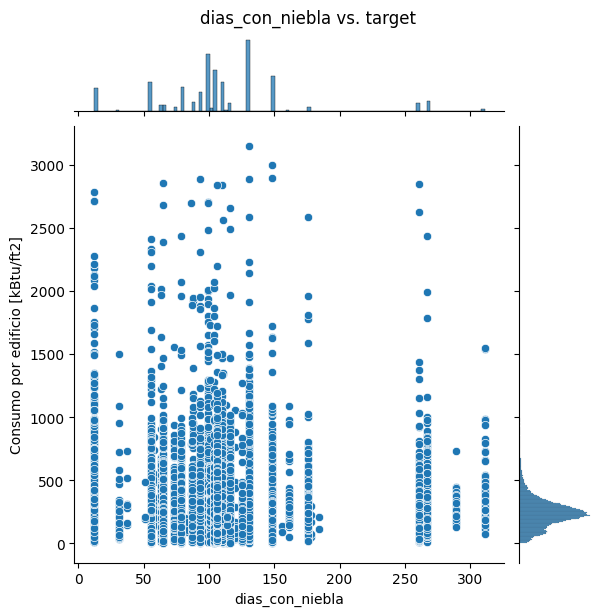

In [78]:
feature = 'dias_con_niebla'
target= 'consumo'

# Gráfico de dispersión
sns.jointplot(x=feature, y=target, data=df, kind="scatter")
plt.suptitle(f'{feature} vs. target', y=1.02)
plt.xlabel('dias_con_niebla')
plt.ylabel('Consumo por edificio [kBtu/ft2]')
plt.show()

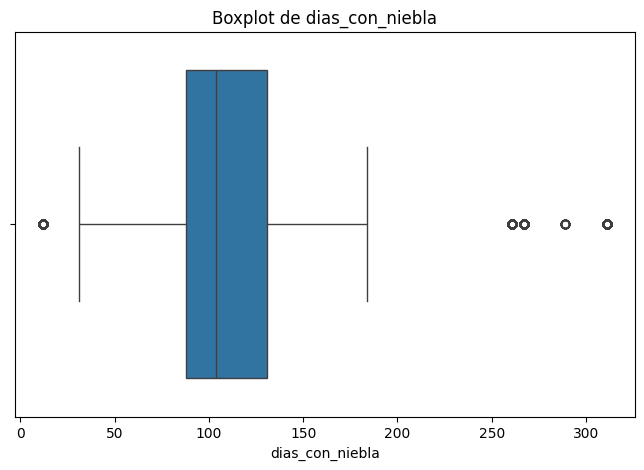

In [79]:
# Boxplot
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['dias_con_niebla'])
plt.title('Boxplot de dias_con_niebla')
plt.xlabel('dias_con_niebla')
plt.show()

Comentario:
* ...
* ...

### 2.6) ANALISIS DE OUTLIERS

Posterior al analisis de los boxplot, hemos notado la presencia de gran cantidad de valores outliers. Por lo cual procederemos a cuantificarlos para ver si es necesario modificar el criterio que establece el boxplot.

In [80]:
estadisticas = df.describe().transpose()
estadisticas

,count,mean,std,min,25%,50%,75%,max
factor_año,75757.0,4.367755,1.471441,1.00,3.00,5.00,6.00,6.00
area_edificio,75757.0,15420.399089,22935.501645,87.61,5795.20,8488.27,15421.90,593221.14
año_construccion,73920.0,1952.306764,37.053619,0.00,1927.00,1951.00,1977.00,2015.00
calificacion_energystar,49048.0,61.048605,28.663683,0.00,40.00,67.00,85.00,100.00
elevacion,75757.0,39.506323,60.656596,-6.40,11.90,25.00,42.70,1924.50
...,...,...,...,...,...,...,...,...
direccion_velocidad_viento_pico,33946.0,62.779974,130.308106,1.00,1.00,1.00,1.00,360.00
velocidad_viento_maxima,34675.0,6.744587,10.394020,1.61,1.61,1.61,1.61,37.50
dias_con_niebla,29961.0,109.142051,50.699751,12.00,88.00,104.00,131.00,311.00
consumo,75757.0,260.521669,183.772498,3.16,172.02,237.52,306.87,3147.87


Al revisar la fila min y max para cada columna, podemos identificar valores que son extremadamente bajos o altos en comparación con el resto de los datos. Por ejemplo, el valor máximo de la variable area_edificio es significativamente mayor que el percentil 75 y que el promedio, esto podría indicar la presencia de outliers.


In [81]:
#Analizamos las columnas que tienen valores maximos mayores a sus percentiles 75.

rango_intercuartil = estadisticas['75%'] - estadisticas['25%']
#print("Rango intercuartil:", rango_intercuartil)
candidatos_outliers_sup = estadisticas[estadisticas['max'] > estadisticas['75%'] + 1.5 * rango_intercuartil]
candidatos_outliers_inf = estadisticas[estadisticas['min'] < estadisticas['25%'] - 1.5 * rango_intercuartil]
candidatos_outliers = pd.concat([candidatos_outliers_sup, candidatos_outliers_inf])
#print(candidatos_outliers)
print(len(candidatos_outliers.index.unique()), "variables con datos candidatos a ser outliers.")

56 variables con datos candidatos a ser outliers.


Encontramos que tenemos 56 variables que presentan valores candidatos a outliers.
Vamos a agregar una columna mas a nuestro dataFrame de estadísticas con los valores límites elegidos hasta ahora para encontrar los valores outliers.

In [82]:
estadisticas['limite_sup_outlier'] = estadisticas['75%'] + 1.5 * rango_intercuartil
estadisticas['limite_inf_outlier'] = estadisticas['25%'] - 1.5 * rango_intercuartil
estadisticas

,count,mean,std,min,25%,50%,75%,max,limite_sup_outlier,limite_inf_outlier
factor_año,75757.0,4.367755,1.471441,1.00,3.00,5.00,6.00,6.00,10.500,-1.500
area_edificio,75757.0,15420.399089,22935.501645,87.61,5795.20,8488.27,15421.90,593221.14,29861.950,-8644.850
año_construccion,73920.0,1952.306764,37.053619,0.00,1927.00,1951.00,1977.00,2015.00,2052.000,1852.000
calificacion_energystar,49048.0,61.048605,28.663683,0.00,40.00,67.00,85.00,100.00,152.500,-27.500
elevacion,75757.0,39.506323,60.656596,-6.40,11.90,25.00,42.70,1924.50,88.900,-34.300
...,...,...,...,...,...,...,...,...,...,...
direccion_velocidad_viento_pico,33946.0,62.779974,130.308106,1.00,1.00,1.00,1.00,360.00,1.000,1.000
velocidad_viento_maxima,34675.0,6.744587,10.394020,1.61,1.61,1.61,1.61,37.50,1.610,1.610
dias_con_niebla,29961.0,109.142051,50.699751,12.00,88.00,104.00,131.00,311.00,195.500,23.500
consumo,75757.0,260.521669,183.772498,3.16,172.02,237.52,306.87,3147.87,509.145,-30.255


Dado que llama la atención que hay muchas variables con valores por fuera de 1.5 veces el rango intercuartil, vamos a ver cuántos outliers hay en cada una de ellas.


In [83]:
cantidades = pd.Series(name='cantidad_outliers')
for col in candidatos_outliers.index:
    print(f"Cantidad de outliers SUPERIOR {col}:", len(df[df[col] > estadisticas['limite_sup_outlier'].loc[col]]))
    print(f"Cantidad de outliers INFERIOR {col}:", len(df[df[col] < estadisticas['limite_inf_outlier'].loc[col]]))

    cantidades[col] = len(df[df[col] > estadisticas['limite_sup_outlier'].loc[col]])


Cantidad de outliers SUPERIOR area_edificio: 8245
Cantidad de outliers INFERIOR area_edificio: 0
Cantidad de outliers SUPERIOR elevacion: 6858
Cantidad de outliers INFERIOR elevacion: 0
Cantidad de outliers SUPERIOR enero_temp_min: 11203
Cantidad de outliers INFERIOR enero_temp_min: 1981
Cantidad de outliers SUPERIOR enero_temp_promedio: 4428
Cantidad de outliers INFERIOR enero_temp_promedio: 232
Cantidad de outliers SUPERIOR enero_temp_max: 2422
Cantidad de outliers INFERIOR enero_temp_max: 1688
Cantidad de outliers SUPERIOR febrero_temp_min: 11
Cantidad de outliers INFERIOR febrero_temp_min: 0
Cantidad de outliers SUPERIOR febrero_temp_promedio: 3299
Cantidad de outliers INFERIOR febrero_temp_promedio: 1689
Cantidad de outliers SUPERIOR febrero_temp_max: 3619
Cantidad de outliers INFERIOR febrero_temp_max: 12466
Cantidad de outliers SUPERIOR marzo_temp_min: 74
Cantidad de outliers INFERIOR marzo_temp_min: 193
Cantidad de outliers SUPERIOR marzo_temp_promedio: 7
Cantidad de outliers I

No es menor el numero de columnas que presenta mas de un 5% de sus datos como outliers. Dado el bulk de datos que manejamos, es necesario revisar el criterio por el cual se define un outlier.

### 2.7) DATOS FALTANTES

A coninuacion se analizan los datos faltantes del dataset

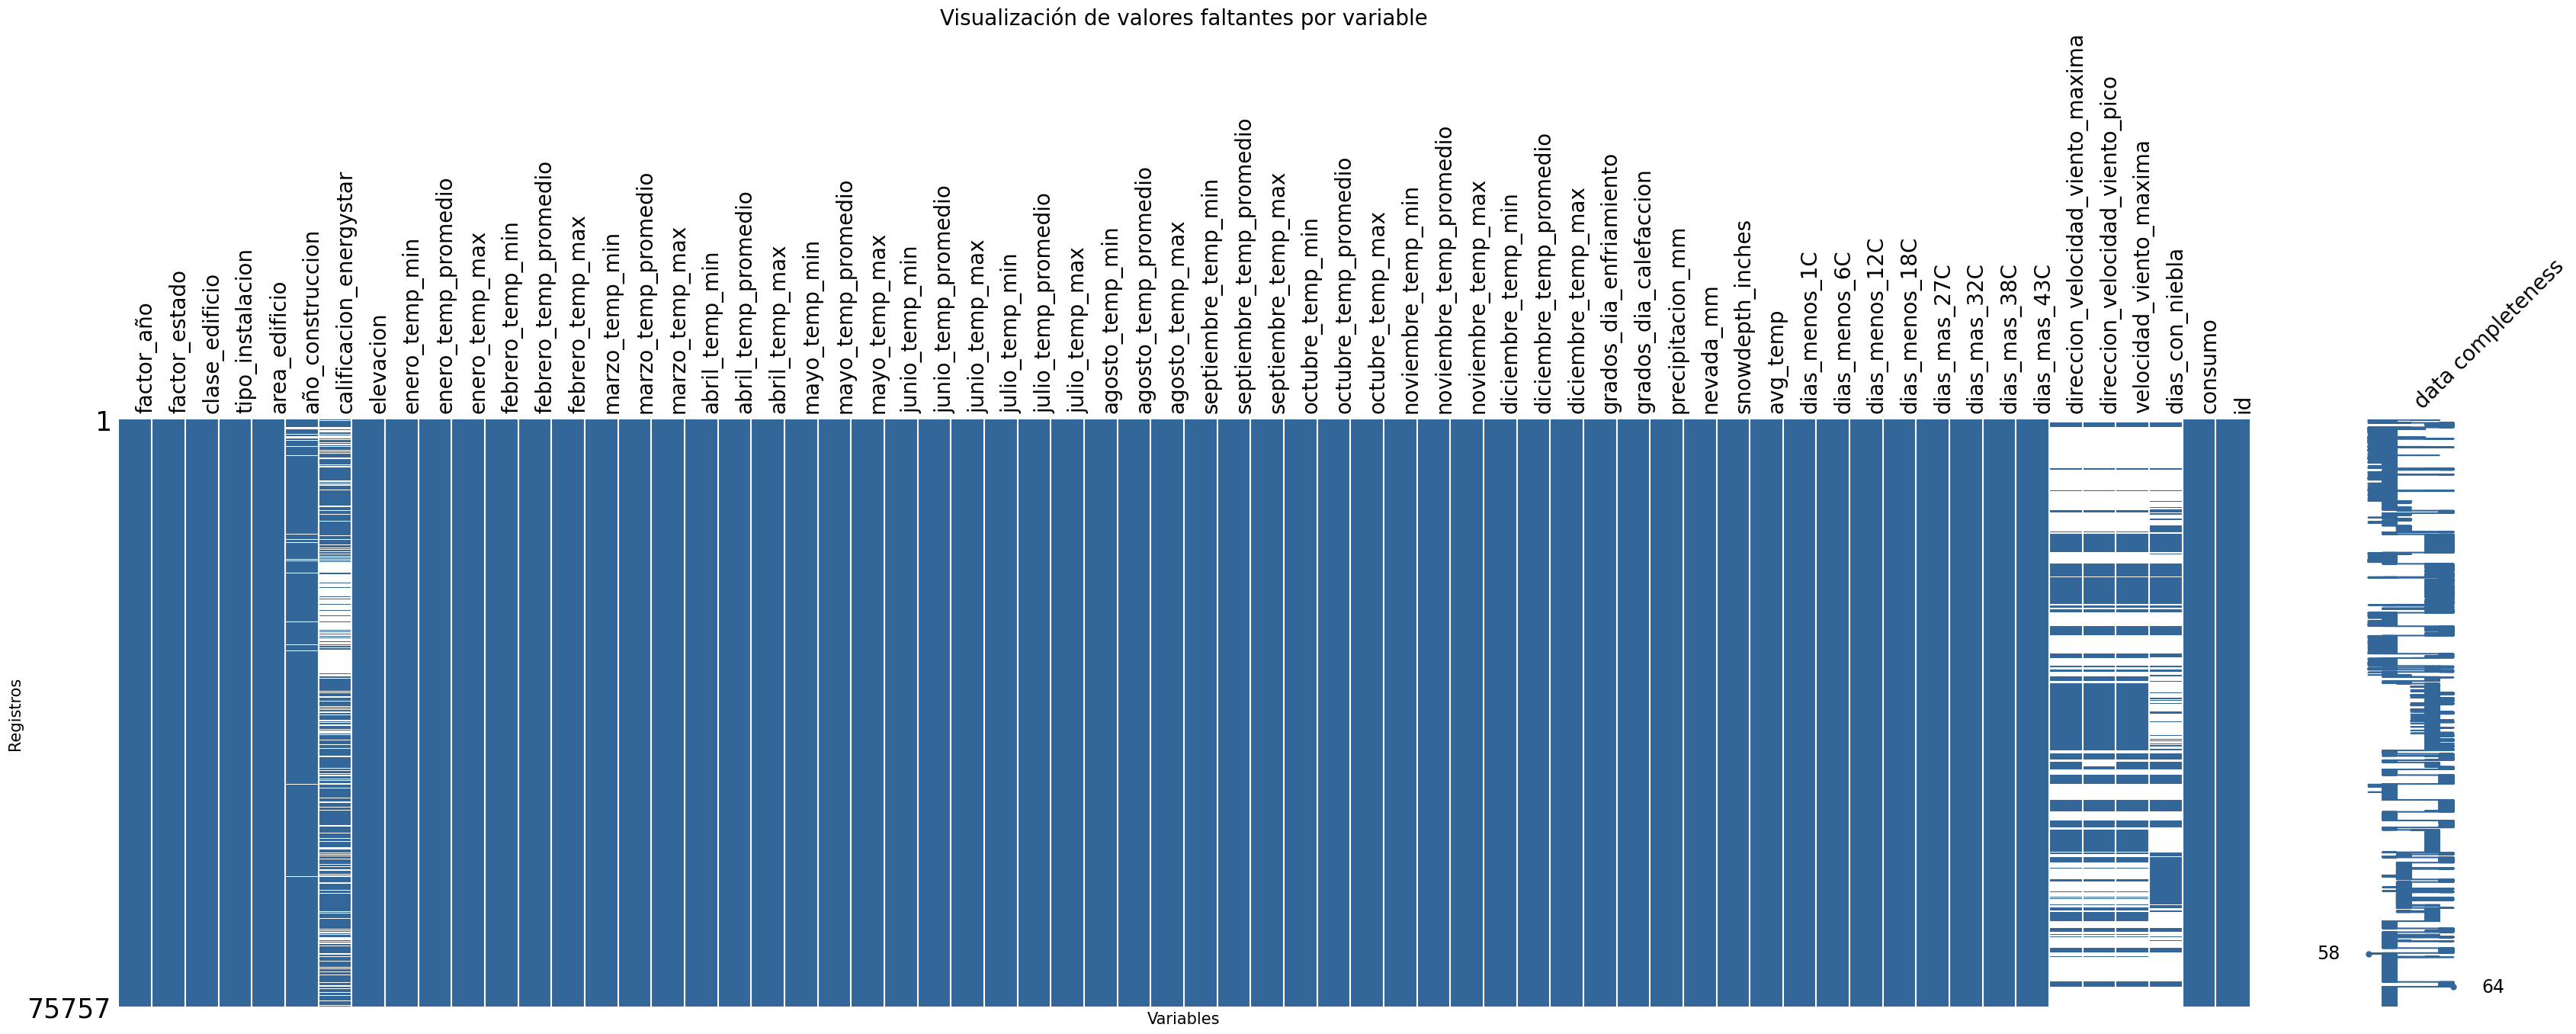

In [84]:
# Gráfico de missing values con nombres de variables rotados y referencias
msno.matrix(df, labels=True, figsize=(40, 10), fontsize=20, color=(0.2, 0.4, 0.6))
plt.xticks(rotation=90)
plt.title('Visualización de valores faltantes por variable', fontsize=20)
plt.xlabel('Variables', fontsize=15)
plt.ylabel('Registros', fontsize=15)
plt.show()

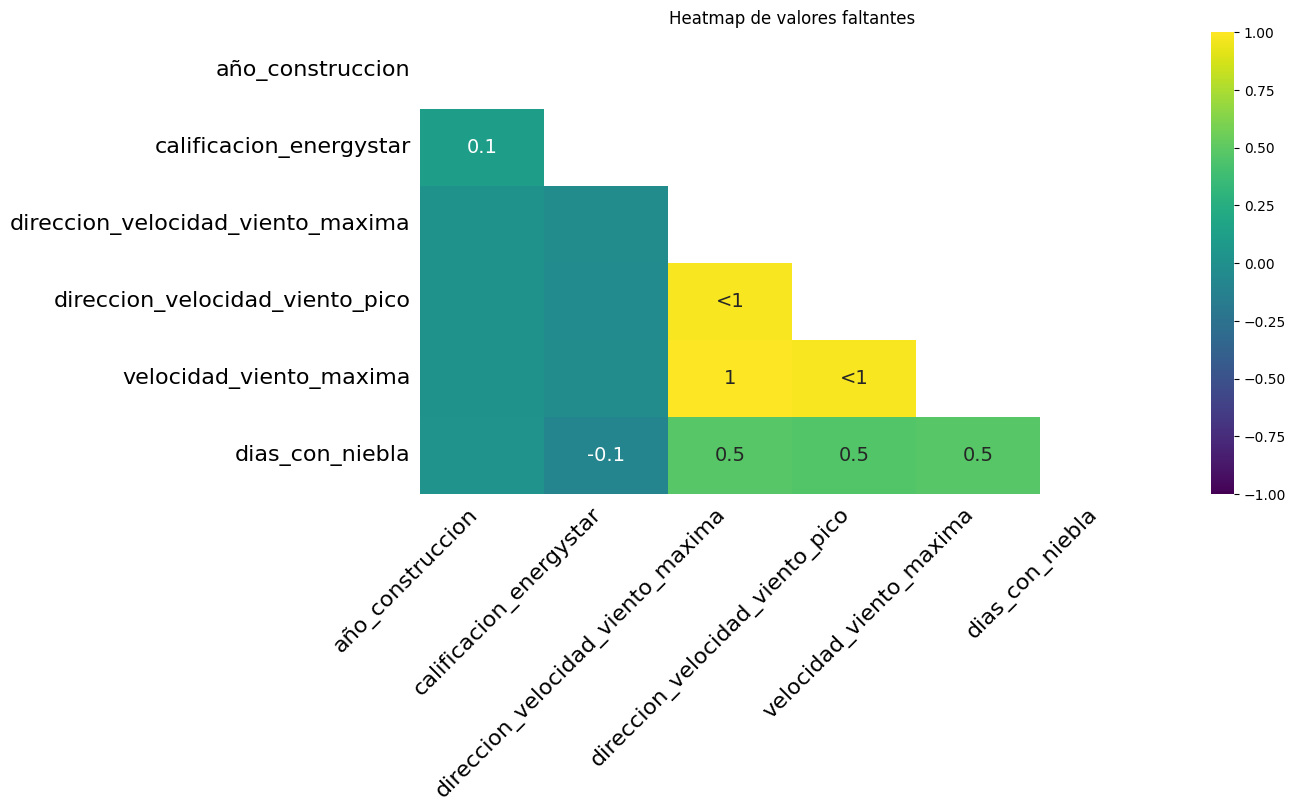

In [85]:
# Gráfico de heatmap de valores faltantes
msno.heatmap(df, figsize=(12, 6), cmap='viridis')
plt.title('Heatmap de valores faltantes')
plt.show()

Para entender este ultimo grafico hay que tener en cuenta que la correlación de nulidad oscila entre:
* -1: si una variable aparece la otra definitivamente no.
* 0: las variables que aparecen o no aparecen no tienen ningún efecto entre sí.
* 1: si una variable aparece la otra definitivamente también.

Se muestran las columnas con la cantidad de datos faltantes

In [86]:
# Calcular la cantidad de datos faltantes por columna
missing_cols = df.columns[df.isnull().any()]
print('--Datos faltantes por columna--\n')
print(df[missing_cols].isnull().sum())
print('-------------------------------\n')

# Calcular el porcentaje de datos faltantes para las columnas en missing_cols
missing_percent = df[missing_cols].isnull().mean() * 100
print('--Porcentaje de datos faltantes por columna--\n')
print(missing_percent)
print('---------------------------------------------\n')

--Datos faltantes por columna--

año_construccion                      1837
calificacion_energystar              26709
direccion_velocidad_viento_maxima    41082
direccion_velocidad_viento_pico      41811
velocidad_viento_maxima              41082
dias_con_niebla                      45796
dtype: int64
-------------------------------

--Porcentaje de datos faltantes por columna--

año_construccion                      2.424858
calificacion_energystar              35.256148
direccion_velocidad_viento_maxima    54.228652
direccion_velocidad_viento_pico      55.190939
velocidad_viento_maxima              54.228652
dias_con_niebla                      60.451179
dtype: float64
---------------------------------------------



Se grafica la matriz de correlacion para entender si hay algun motivo para los datos faltantes asociados al viento

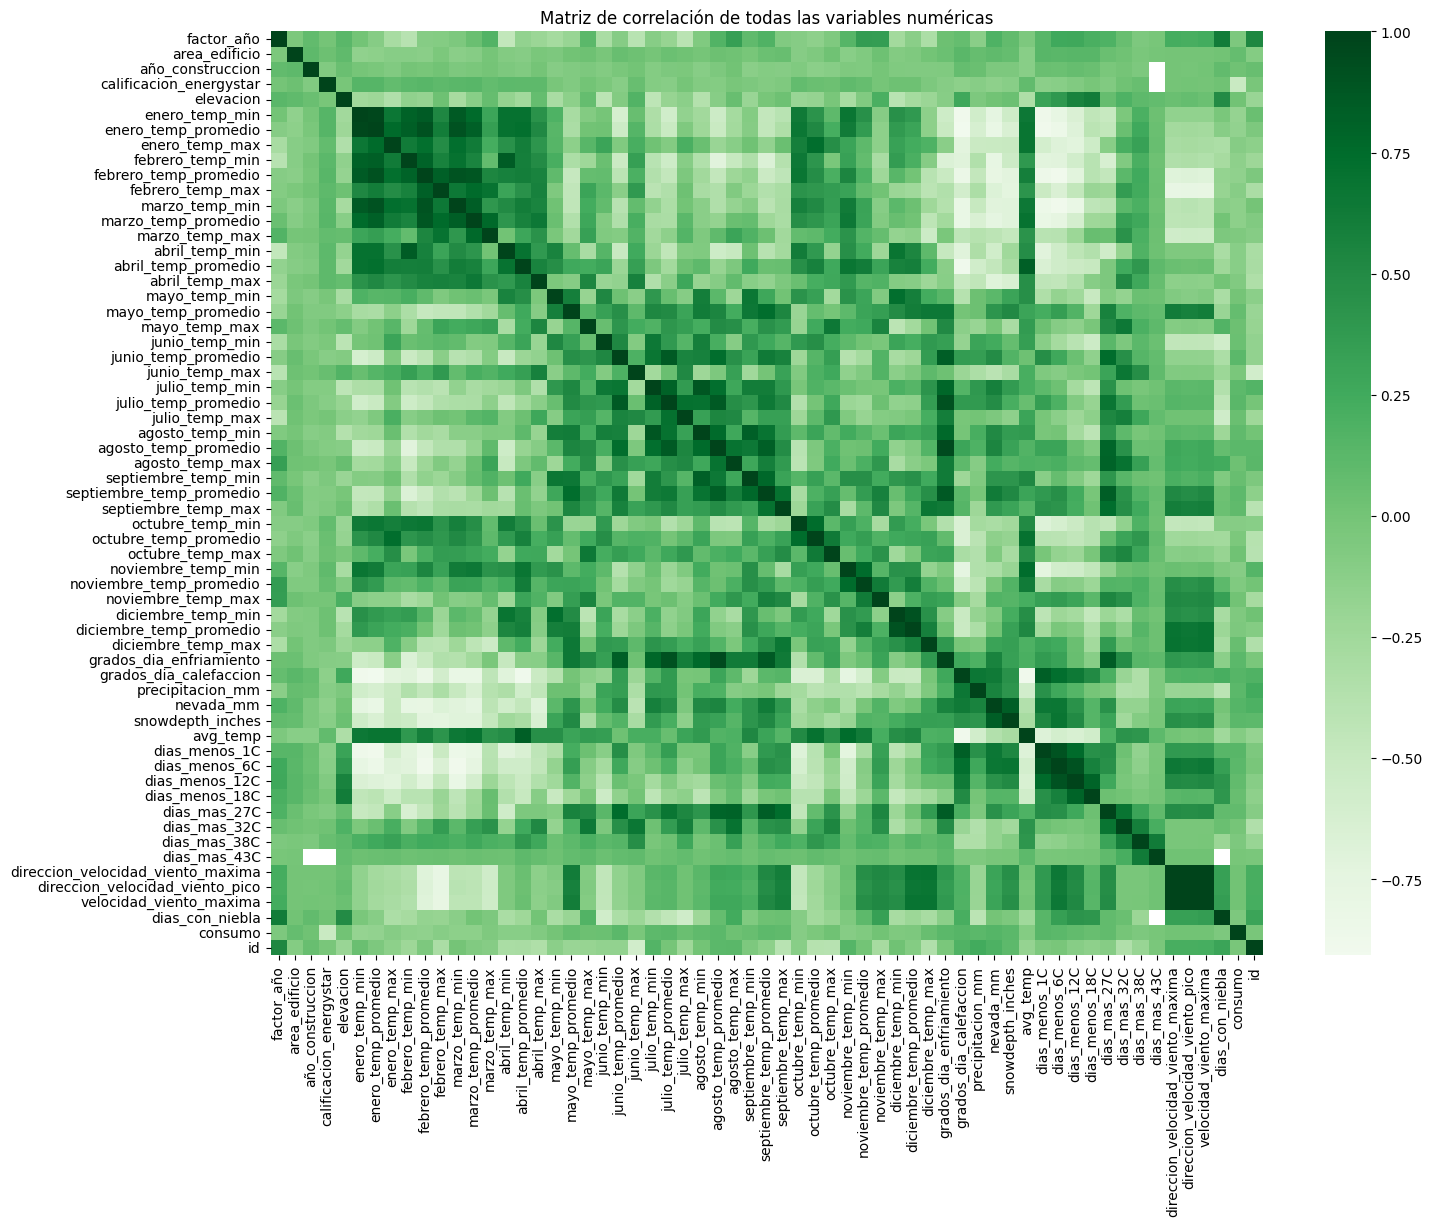

In [87]:
# Generar la matriz de correlación para todas las variables numéricas de df
correlation_matrix_full = df.corr(numeric_only=True)

# Mostrar la matriz de correlación completa
plt.figure(figsize=(16, 12))
sns.heatmap(correlation_matrix_full, cmap='Greens', center=0)
plt.title('Matriz de correlación de todas las variables numéricas')
plt.show()

Si bien se observan que tienen una correlacion importante con algunas variables (_**may_avg_temp**_, _**december_avg_temp**_, entre otras), pero esto no explica el porque del dato faltante.

Se grafica el histograma de estas variables para seguir analizando

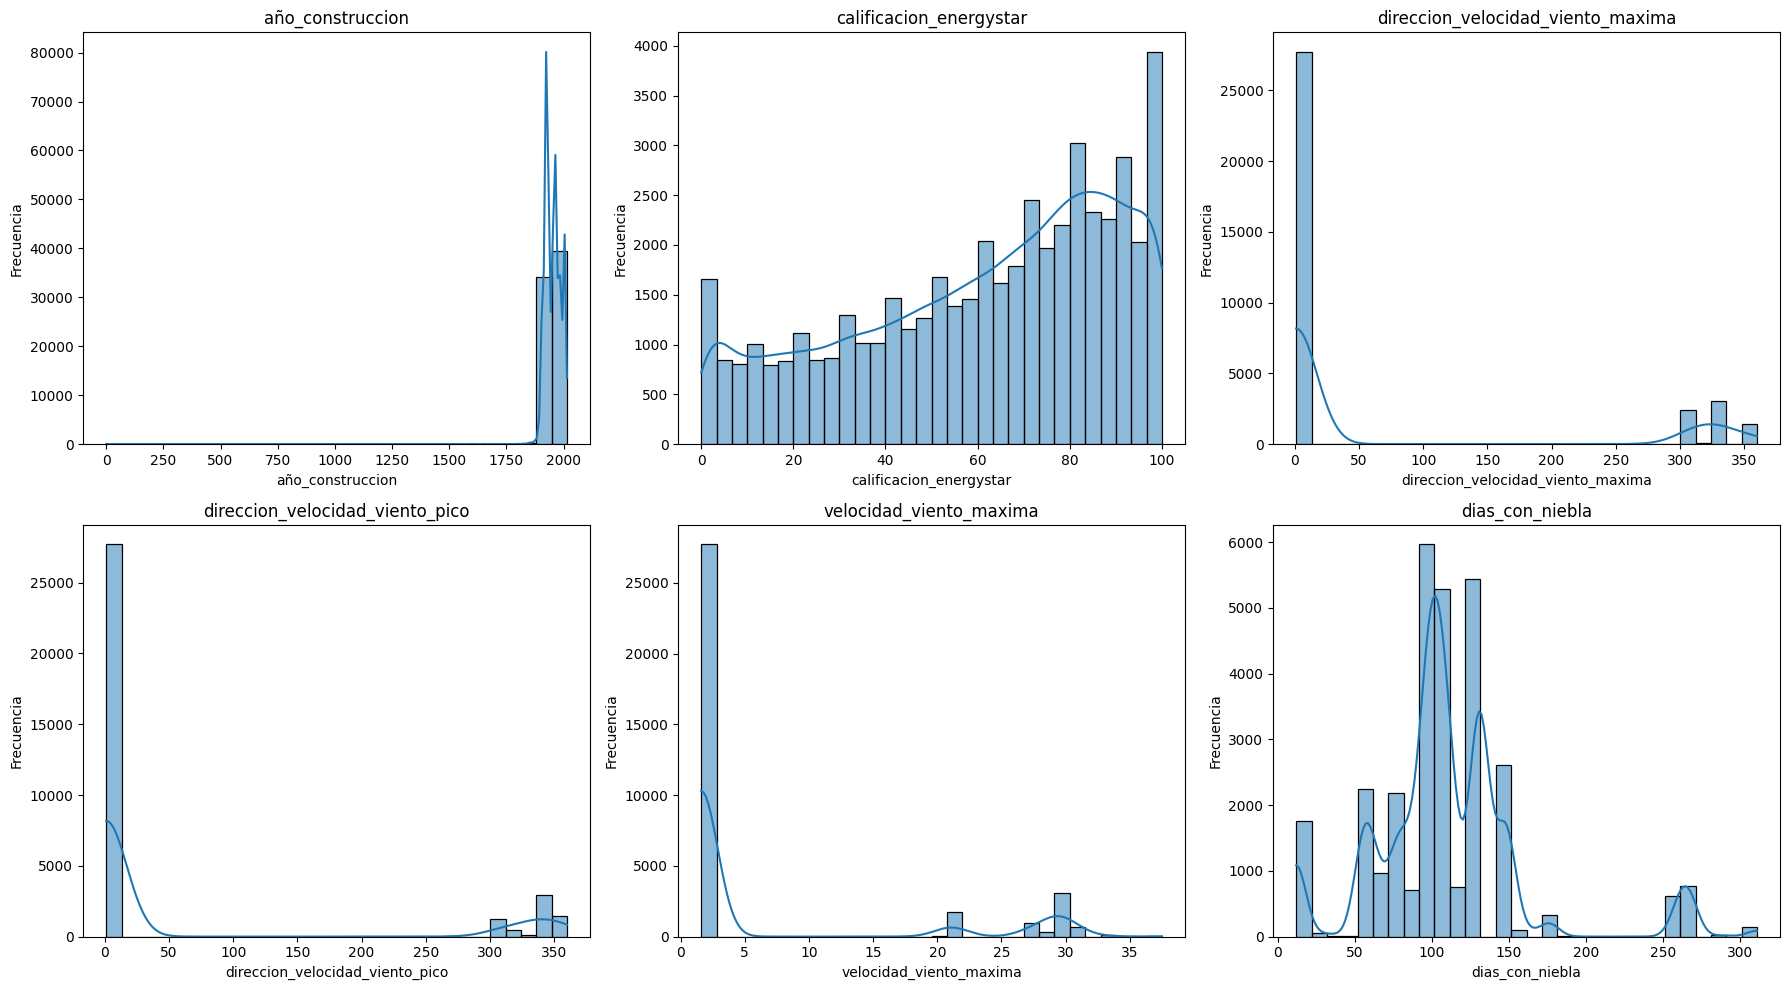

In [88]:
variables = ['año_construccion', 'calificacion_energystar', 'direccion_velocidad_viento_maxima',
             'direccion_velocidad_viento_pico', 'velocidad_viento_maxima', 'dias_con_niebla']

plt.figure(figsize=(18, 10))
for i, var in enumerate(variables, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df[var], kde=True, bins=30)
    plt.title(var)
    plt.xlabel(var)
    plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

Observaciones:
* _**año_construccion**_: Se puede observar que tiene algunos datos extremos por debajo de la media. En este caso se podrian imputar los datos faltantes.
* _**calificacion_energystar**_: Se observa que tiene una distribusion bastante uniforme o creciente hacia la derecha. En este caso los datos faltantes tambien se podrias imputar mediante una tecnica avanzada de imputacion multiple.
* _**direccion_velocidad_viento_maxima**_: Se puede observar que la mayoria de los datos estan proximos al cero, lo cual puede indicar la direccion o puede ser un dato mal registrado.
* _**direccion_velocidad_viento_pico**_: idem anterior
* _**velocidad_viento_kmh**_: En este caso, que la mayoria de los datos este proximo al cero es cuestionable ya que estamos hablAndo de la velocidad maxima del viento.
* _**dias_con_niebla**_: Se observa una distribucion normal con algunos valores extremos a la derecha.

## CONCLUSIONES
* **¿Cuántos datos tiene mi data set?**
  * El data set cuenta con 75757 Filas y 64 Columnas.
  
  Para mayor detalle ver el [punto 2.3](#scrollTo=ZiPn7IYr7jcb&line=1&uniqifier=1).

  


* **¿Cuántas features tengo? ¿De qué tipo son?**
  * De las 64 variables del data set, tenemos 3 tipos de datos distintos:
    * 37 son del tipo **int**
    * 24 son del tipo **float**
    * 3 son del tipo **object**
  
  Para mayor detalle ver el [punto 2.3](#scrollTo=ZiPn7IYr7jcb&line=1&uniqifier=1).

  

* **¿A cuáles les deberé aplicar alguna transformación?**
  * Ver [punto 2.4](#scrollTo=zQwa9ckU7jcc&line=1&uniqifier=1).

  

* **¿Cuál es mi variable target? ¿Qué significa?**
  * La variable a predecir es **consumo**: cantidad de calor y electricidad consumidos por un edificio (medido en kBtu/ft2)

  Para mayor detalle ver el [punto 1](#scrollTo=1pJ7qcUePgQL&line=1&uniqifier=1).

  

* **¿Todas las features aportan información diferente?**
  * Se observa que no hay muchas variables con una correlacion muy elevada (> al 0,5) en ralacion a la variable a predecir. Solo encontramos la variable _**calificacion_energystar**_.

  Para mayor detalle ver el [punto 2.4](#scrollTo=LZs3yIHd7jcd).



* **¿Existen datos faltantes? ¿Qué me convendrá hacer con ellos?**
  * Se observan datos faltantes en 6 de las 64 variables. Se proponen eliminar los registros con datos faltantes o imputar dependiendo cada caso.
  
  Para mayor detalle ver el [punto 2.7](#scrollTo=k3xOXJMF7jcd&line=1&uniqifier=1).


---



## 3) ANALISIS ESTADISTICO

### 3.1) FEATURES DE INTERES

Se genera nuevamente la matriz de correlacion para detectar las features de mayor interes

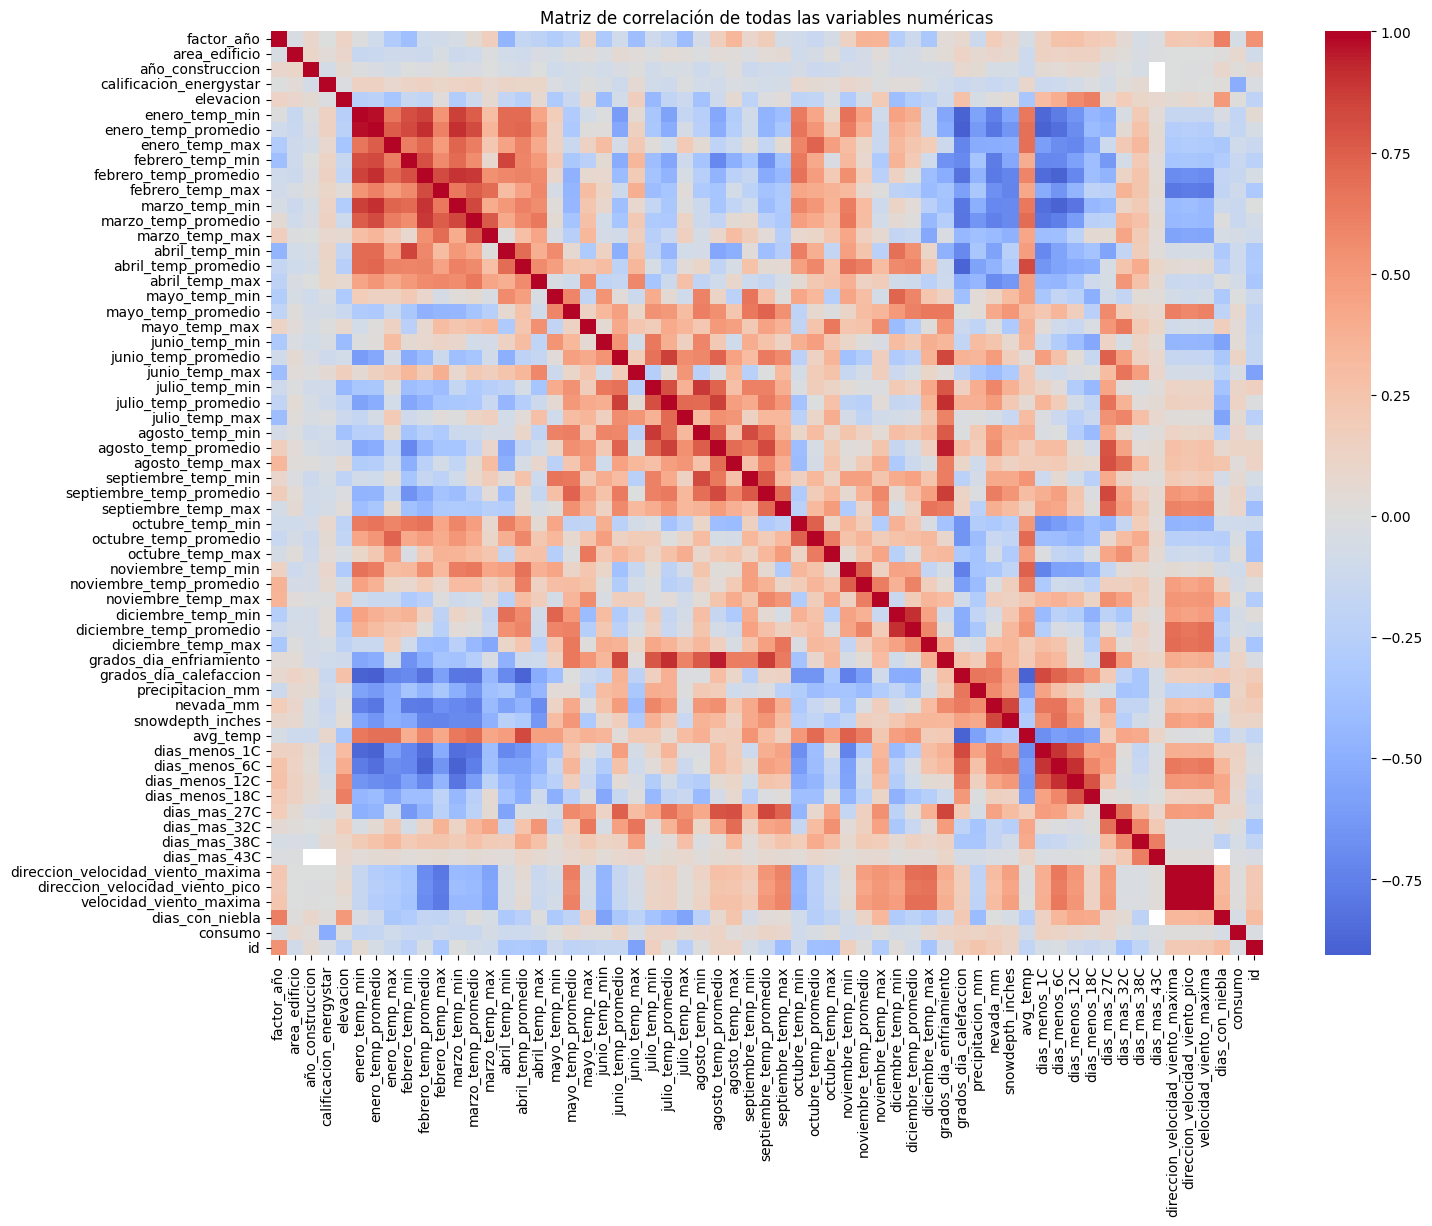

In [89]:
# Generar la matriz de correlación para todas las variables numéricas de df
correlation_matrix_full = df.corr(numeric_only=True)

# Mostrar la matriz de correlación completa
plt.figure(figsize=(16, 12))
sns.heatmap(correlation_matrix_full, cmap='coolwarm', center=0)
plt.title('Matriz de correlación de todas las variables numéricas')
plt.show()

Realizamos el grafico de la matriz de correlacion para la variable a predecir para poder apreciar mejor la información con una visualización rápida.

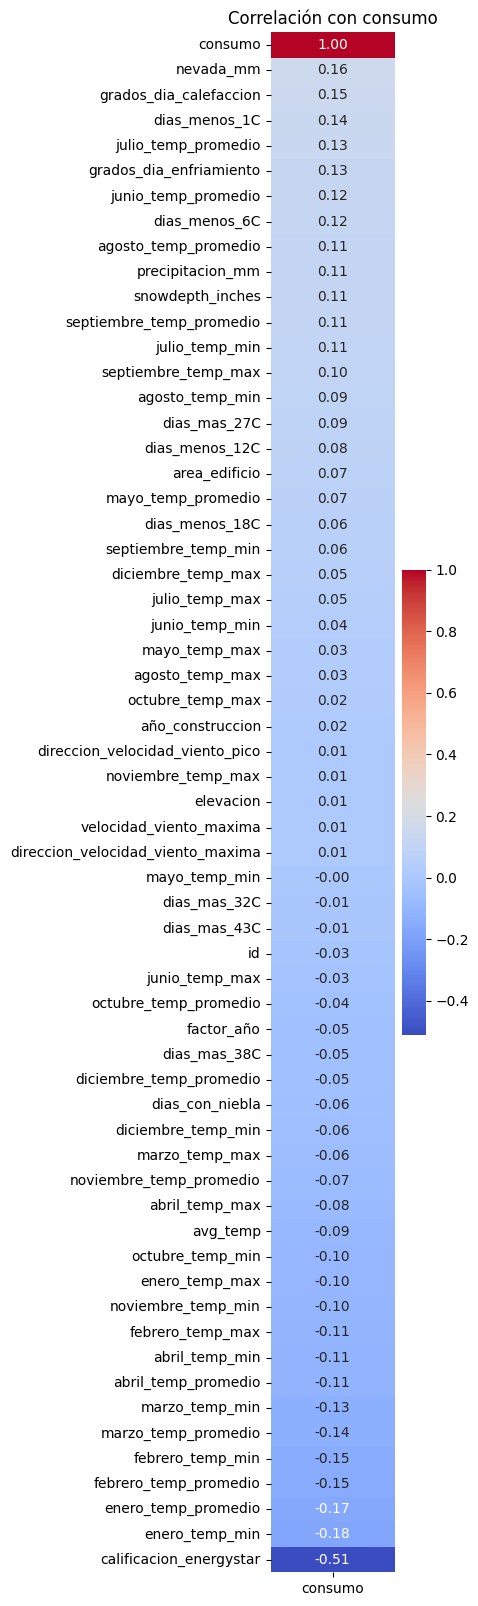

In [90]:
# Seleccionar solo las columnas numéricas para la matriz de correlación
df_numeric = df.select_dtypes(include=np.number)

# Generar la matriz de correlación
correlation_matrix = df_numeric.corr()

# Resaltar la columna 'consumo' en la matriz de correlación usando un mapa de calor
plt.figure(figsize=(2, 20))
sns.heatmap(correlation_matrix[['consumo']].sort_values(by='consumo', ascending=False), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlación con consumo')
plt.show()

Se observa que no hay muchas variables con una correlacion muy elevada (> al 0,5). Solo encontramos que la variable _**calificacion_energystar**_ satisface esta característica.


Realizamos una visualizacion de las que se encuentran en el TOP 10 para distinguir cuales variables les siguen.

/tmp/ipython-input-91-4229120136.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_correlations.index, y=top_correlations.values, palette='viridis')


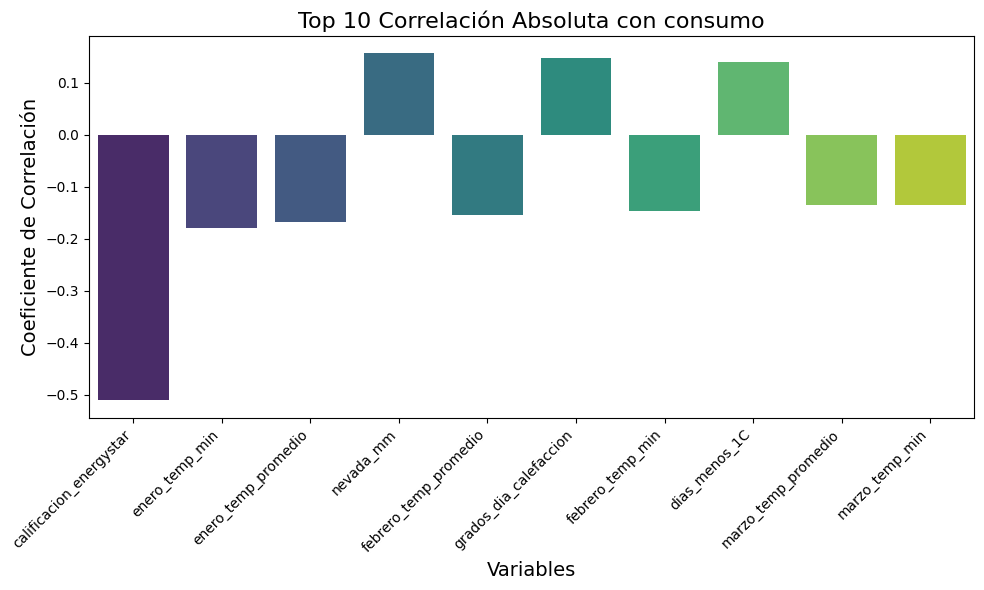

In [91]:
# Obtener las correlaciones de todas las variables numéricas con 'consumo'
correlation_with_eui = df_numeric.corr()['consumo'].sort_values(ascending=False)

# Eliminar la correlación de 'consumo' consigo misma
correlation_with_eui = correlation_with_eui.drop('consumo')

# Seleccionar las 10 variables con mayor correlación (positiva o negativa) absoluta
top_correlated_features = correlation_with_eui.abs().nlargest(10).index.tolist()
top_correlations = correlation_with_eui[top_correlated_features]

# Crear el gráfico de barras
plt.figure(figsize=(10, 6))
sns.barplot(x=top_correlations.index, y=top_correlations.values, palette='viridis')
plt.title('Top 10 Correlación Absoluta con consumo', fontsize=16)
plt.xlabel('Variables', fontsize=14)
plt.ylabel('Coeficiente de Correlación', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## CONCLUSIONES
* **¿Qué herramienta/s es/son la/s más adeduada/s para seleccionar features de interés? ¿Cuál es el criterio para realizar dicha selección?**
  * Las herramientas mas adecuadas para seleccionar features de interes son el analisis descriptivo y estadistico ya que permiten entender la distribución de cada variable (histogramas), detectar outliers o valores atípicos que podrían distorsionar el modelo (boxplot), identificar relaciones entre variables (matriz de correlaciones), entre otras.
  * El criterio a utilizar es aquellas variables que cumplan con la condicion de presentar un coeficiente de correlacion mayor a 0,5.
    
  **Posterior a todo este analisis, sin tener en cuenta la variable _'calificacion_energystar'_, no pueden identificarse features que ayuden al modelo de prediccion.**
  

---



* **¿Existen outliers para estos features?**
  
  No presenta outliers
<br>

* **¿Hay valores faltantes?**
  
  Si, tiene 26709 datos faltantes que representan el 35,25% del total.
<br>

* **¿Hay valores que no corresponden?**

  En esta primera evaluacion no hemos detectado ningun dato que no corresponda.

<br>

* **¿Que decisión tomarían para completar o eliminar estos outliers y faltantes?**

  Dada la distribucion de datos faltantes, la imputacion por k vecinos cercanos resultaria apropiada.

<br>

* **¿Cómo es la distribución de las variables en el dataset?**

  Tiene una distribucion uniforme con una pequeña tendencia a una asimetria hacia la izquierda.





